In [1]:
import warnings
warnings.simplefilter('ignore')

PROBLEM STATEMENT: Build a Credit Score using Machine Learning and that indicates the likelihood of loan repayment

In [2]:
#import numpy,matplotlib,pandas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#load the dataset
Load_DS=pd.read_csv('loan_data_2007_2014.csv')

#print the basic info of the dataframe
Load_DS.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

# PRE-PROCESSING

In [4]:
#check the emp-length column unique values
Load_DS['emp_length'].unique()

array(['10+ years', '< 1 year', '1 year', '3 years', '8 years', '9 years',
       '4 years', '5 years', '6 years', '2 years', '7 years', nan],
      dtype=object)

In [5]:
#replace all the extra letters and convert this column into numeric format

#one-sample conversion code is written write for the rest
Load_DS['emp_length_int']=Load_DS['emp_length'].str.replace('10+ years',str(10))

Load_DS['emp_length_int']=Load_DS['emp_length_int'].str.replace('< 1 year',str(0))

Load_DS['emp_length_int']=Load_DS['emp_length_int'].str.replace('year','')

Load_DS['emp_length_int']=Load_DS['emp_length_int'].str.replace(' s','')

Load_DS['emp_length_int']=Load_DS['emp_length_int'].fillna(str(0))

Load_DS['emp_length_int'].unique()

array(['10', '0', '1 ', '3', '8', '9', '4', '5', '6', '2', '7'],
      dtype=object)

In [6]:
#check the type of emp_length_int
type(Load_DS['emp_length_int'][0])

str

In [7]:
#convert it into numerical format
Load_DS['emp_length_int']=pd.to_numeric(Load_DS['emp_length_int'])

In [8]:
#check the type of emp_length_int
type(Load_DS['emp_length_int'][0])

numpy.int64

In [9]:
#print the dataframe
Load_DS

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,emp_length_int
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466280,466280,8598660,1440975,18400,18400,18400.0,60 months,14.47,432.64,C,...,NaN,NaN,NaN,NaN,NaN,29900.0,NaN,NaN,NaN,4
466281,466281,9684700,11536848,22000,22000,22000.0,60 months,19.97,582.50,D,...,NaN,NaN,NaN,NaN,NaN,39400.0,NaN,NaN,NaN,10
466282,466282,9584776,11436914,20700,20700,20700.0,60 months,16.99,514.34,D,...,NaN,NaN,NaN,NaN,NaN,13100.0,NaN,NaN,NaN,7
466283,466283,9604874,11457002,2000,2000,2000.0,36 months,7.90,62.59,A,...,NaN,NaN,NaN,NaN,NaN,53100.0,NaN,NaN,NaN,3


In [10]:
#check the unique values of term column
Load_DS['term'].unique()

array([' 36 months', ' 60 months'], dtype=object)

In [11]:
#do all the necesaary replacements to convert into numeric
Load_DS['term_int']=Load_DS['term'].str.replace('months','')

In [12]:
#check the type of term_int
type(Load_DS['term_int'][0])

str

In [13]:
#convert it into numerical format
Load_DS['term_int']=pd.to_numeric(Load_DS['term_int'])

In [14]:
#check the type
type(Load_DS['term_int'][0])

numpy.int64

In [15]:
#check for the column called earliest_cr_line
Load_DS['earliest_cr_line']

0         Jan-85
1         Apr-99
2         Nov-01
3         Feb-96
4         Jan-96
           ...  
466280    Apr-03
466281    Jun-97
466282    Dec-01
466283    Feb-03
466284    Feb-00
Name: earliest_cr_line, Length: 466285, dtype: object

In [16]:
#convert into datetime
Load_DS['earliest_cr_line_date']=pd.to_datetime(Load_DS['earliest_cr_line'], format='%b-%y')

In [17]:
#check the newly created column i.e 'earliest_cr_line_date'
Load_DS['earliest_cr_line_date']

0        1985-01-01
1        1999-04-01
2        2001-11-01
3        1996-02-01
4        1996-01-01
            ...    
466280   2003-04-01
466281   1997-06-01
466282   2001-12-01
466283   2003-02-01
466284   2000-02-01
Name: earliest_cr_line_date, Length: 466285, dtype: datetime64[ns]

In [18]:
#get the total number of days from current date i.e present date
from datetime import date
pd.to_datetime('2024-06-30')-Load_DS['earliest_cr_line_date']

0        14425 days
1         9222 days
2         8277 days
3        10377 days
4        10408 days
            ...    
466280    7761 days
466281    9891 days
466282    8247 days
466283    7820 days
466284    8916 days
Name: earliest_cr_line_date, Length: 466285, dtype: timedelta64[ns]

In [19]:
#convert these days into months i.e converting days into months
Load_DS['mths_since_earliest_cr_line']=round(pd.to_numeric((pd.to_datetime('2024-06-30')-Load_DS['earliest_cr_line_date'])/np.timedelta64(1,'D'))/30)

In [20]:
#check the basic statistics of 'mths_since_earliest_cr_line'
Load_DS['mths_since_earliest_cr_line'].describe()

count    466256.000000
mean        323.071553
std          95.345469
min        -541.000000
25%         266.000000
50%         308.000000
75%         369.000000
max         676.000000
Name: mths_since_earliest_cr_line, dtype: float64

In [21]:
#check the dataframe for column that have negative months which is not possible
Load_DS.loc[: , ['earliest_cr_line','earliest_cr_line_date','mths_since_earliest_cr_line']][Load_DS['mths_since_earliest_cr_line']<0]

,earliest_cr_line,earliest_cr_line_date,mths_since_earliest_cr_line
1580,Sep-62,2062-09-01,-465.0
1770,Sep-68,2068-09-01,-538.0
2799,Sep-64,2064-09-01,-489.0
3282,Sep-67,2067-09-01,-526.0
3359,Feb-65,2065-02-01,-494.0
...,...,...,...
464003,Jan-68,2068-01-01,-530.0
464260,Jul-66,2066-07-01,-511.0
465100,Oct-67,2067-10-01,-527.0
465500,Sep-67,2067-09-01,-526.0


In [22]:
#replace all the negative values with the max months value
Load_DS['mths_since_earliest_cr_line'][Load_DS['mths_since_earliest_cr_line'] < 0 ]=Load_DS['mths_since_earliest_cr_line'].max()

In [23]:
#again check the basic stats so that no months are negative
Load_DS['mths_since_earliest_cr_line'].describe()

count    466256.000000
mean        326.017780
std          87.723885
min         154.000000
25%         267.000000
50%         309.000000
75%         369.000000
max         676.000000
Name: mths_since_earliest_cr_line, dtype: float64

In [24]:
#check the issue_d column
Load_DS['issue_d']

0         Dec-11
1         Dec-11
2         Dec-11
3         Dec-11
4         Dec-11
           ...  
466280    Jan-14
466281    Jan-14
466282    Jan-14
466283    Jan-14
466284    Jan-14
Name: issue_d, Length: 466285, dtype: object

In [25]:
Load_DS['issue_date']=pd.to_datetime(Load_DS['issue_d'],format='%b-%y')

In [26]:
type(Load_DS['issue_date'][0])

pandas._libs.tslibs.timestamps.Timestamp

In [27]:
#get the number of days from present date
pd.to_datetime('2024-06-30')-Load_DS['issue_date']

0        4595 days
1        4595 days
2        4595 days
3        4595 days
4        4595 days
            ...   
466280   3833 days
466281   3833 days
466282   3833 days
466283   3833 days
466284   3833 days
Name: issue_date, Length: 466285, dtype: timedelta64[ns]

In [28]:
#convert days to months
Load_DS['mths_since_issued_date']=round(pd.to_numeric((pd.to_datetime('2024-06-30')-Load_DS['issue_date'])/np.timedelta64(1,'D'))/30)

In [29]:
#check the basic stats
Load_DS['mths_since_issued_date'].describe()

count    466285.000000
mean        132.271518
std          14.403925
min         117.000000
25%         122.000000
50%         128.000000
75%         138.000000
max         208.000000
Name: mths_since_issued_date, dtype: float64

In [30]:
min(Load_DS['mths_since_issued_date'])

117.0

In [31]:
#check the 'delinq_2yrs' column and convert it into float type
Load_DS['delinq_2yrs']=Load_DS['delinq_2yrs'].astype(float)

In [32]:
#check the basic stats
Load_DS['delinq_2yrs'].describe()

count    466256.000000
mean          0.284678
std           0.797365
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          29.000000
Name: delinq_2yrs, dtype: float64

PREPROCESSING MISSING DATA

In [33]:
#Get the dummies value for the column 'grade'
pd.get_dummies(Load_DS['grade'],prefix='grade',prefix_sep=':',dtype=int)

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G
0,0,1,0,0,0,0,0
1,0,0,1,0,0,0,0
2,0,0,1,0,0,0,0
3,0,0,1,0,0,0,0
4,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...
466280,0,0,1,0,0,0,0
466281,0,0,0,1,0,0,0
466282,0,0,0,1,0,0,0
466283,1,0,0,0,0,0,0


In [34]:
#Similarly apply the dummy creation step for 'grade','sub_grade','home_ownership','verification_status','loan_status','purpose','addr_state','initial_list_status' in one list_comprehension
Load_dumies_Data=[pd.get_dummies(Load_DS['grade'],prefix='grade',prefix_sep=':',dtype=int),
                 pd.get_dummies(Load_DS['sub_grade'],prefix='sub_grade',prefix_sep=':',dtype=int),
                 pd.get_dummies(Load_DS['home_ownership'],prefix='home_ownership',prefix_sep=':',dtype=int),
                 pd.get_dummies(Load_DS['verification_status'],prefix='verification_status',prefix_sep=':',dtype=int),
                 pd.get_dummies(Load_DS['loan_status'],prefix='loan_status',prefix_sep=':',dtype=int),
                 pd.get_dummies(Load_DS['purpose'],prefix='purpose',prefix_sep=':',dtype=int),
                 pd.get_dummies(Load_DS['addr_state'],prefix='addr_state',prefix_sep=':',dtype=int),
                 pd.get_dummies(Load_DS['initial_list_status'],prefix='initial_list_status',prefix_sep=':',dtype=int)]                                                                             

In [35]:
#concat all and create a dataframe
Load_dumies_Data=pd.concat(Load_dumies_Data, axis=1)

In [36]:
#check the dummy var dataframe
Load_dumies_Data

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G,sub_grade:A1,sub_grade:A2,sub_grade:A3,...,addr_state:TX,addr_state:UT,addr_state:VA,addr_state:VT,addr_state:WA,addr_state:WI,addr_state:WV,addr_state:WY,initial_list_status:f,initial_list_status:w
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466280,0,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
466281,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
466282,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
466283,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [37]:
type(Load_dumies_Data)

pandas.core.frame.DataFrame

In [38]:
#concatenate this dummy var dataframe with the original Load_DS dataframe
Load_DS=pd.concat([Load_DS,Load_dumies_Data], axis=1)

In [39]:
#check the column names
Load_DS.columns.values

array(['Unnamed: 0', 'id', 'member_id', 'loan_amnt', 'funded_amnt',
       'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade',
       'sub_grade', 'emp_title', 'emp_length', 'home_ownership',
       'annual_inc', 'verification_status', 'issue_d', 'loan_status',
       'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code',
       'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line',
       'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'out_prncp',
       'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
       'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
       'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
       'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint',
       'veri

MISSING VALUES

In [40]:
#check the missing values
Load_DS.isnull()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,addr_state:TX,addr_state:UT,addr_state:VA,addr_state:VT,addr_state:WA,addr_state:WI,addr_state:WV,addr_state:WY,initial_list_status:f,initial_list_status:w
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466280,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
466281,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
466282,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
466283,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [41]:
pd.options.display.max_rows= None

In [42]:
#print the sum of all null values of all columns
Load_DS.isnull().sum()

Unnamed: 0                                                              0
id                                                                      0
member_id                                                               0
loan_amnt                                                               0
funded_amnt                                                             0
funded_amnt_inv                                                         0
term                                                                    0
int_rate                                                                0
installment                                                             0
grade                                                                   0
sub_grade                                                               0
emp_title                                                           27588
emp_length                                                          21008
home_ownership                        

In [43]:
pd.options.display.max_rows =100

In [44]:
#fill the null values in column 'total_rev_hi_lim' with Loan_DS['funded_amt']
Load_DS['total_rev_hi_lim'].fillna(Load_DS['funded_amnt'], inplace=True)

In [45]:
#check the null values in column 'total_rev_hi_lim'
Load_DS['total_rev_hi_lim'].isnull().sum()

np.int64(0)

In [46]:
#fill the 'annual_inc' null values with mean value of 'annual_inc' column
Load_DS['annual_inc'].fillna(Load_DS['annual_inc'].mean(), inplace=True)

In [47]:
#check the null values in 'annual_inc'
Load_DS['annual_inc'].isnull().sum()

np.int64(0)

In [48]:
#fill all null values in column 'mths_since_earliest_cr_line' with '0'
Load_DS['mths_since_earliest_cr_line'].fillna('0', inplace=True)

In [49]:
#check the sum of null values for this column
Load_DS['mths_since_earliest_cr_line'].isnull().sum()

np.int64(0)

In [50]:
#fill all null values in column 'acc_now_delinq' with '0'
Load_DS['acc_now_delinq'].fillna('0', inplace=True)

In [51]:
#check the sum of null values for this column
Load_DS['acc_now_delinq'].isnull().sum()

np.int64(0)

In [52]:
#fill all null values in column 'total_acc' with '0'
Load_DS['total_acc'].fillna('0', inplace=True)

In [53]:
#similary fill the columns 'pub_rec','open_acc','inq_last_6mths','delinq_2yrs','emp_length_int' with '0'
Load_DS['pub_rec'].fillna('0',inplace=True)
Load_DS['open_acc'].fillna('0',inplace=True)
Load_DS['inq_last_6mths'].fillna('0',inplace=True)
Load_DS['delinq_2yrs'].fillna('0',inplace=True)
Load_DS['emp_length_int'].fillna('0', inplace=True)

PD(PROBABLITY OF DEFAULT)

Building the Weight of expectancy values (WOE)

In [54]:
#check the unique values in our final output column i.e 'loan_status'
Load_DS['loan_status'].unique()

array(['Fully Paid', 'Charged Off', 'Current', 'Default',
       'Late (31-120 days)', 'In Grace Period', 'Late (16-30 days)',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [55]:
#check the value_counts for loan_status
Load_DS['loan_status'].value_counts()

loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

In [56]:
#check the percentage of distribution
Load_DS['loan_status'].value_counts()/Load_DS['loan_status'].count()

loan_status
Current                                                0.480878
Fully Paid                                             0.396193
Charged Off                                            0.091092
Late (31-120 days)                                     0.014798
In Grace Period                                        0.006747
Does not meet the credit policy. Status:Fully Paid     0.004263
Late (16-30 days)                                      0.002612
Default                                                0.001784
Does not meet the credit policy. Status:Charged Off    0.001632
Name: count, dtype: float64

In [57]:
#binary encoding of our target variable
Load_DS['good_bad']=np.where(Load_DS['loan_status'].isin(['Charged Off','Default','Does not meet the credit policy. Status:Charged Off','Late (31-120 days)']),0,1)

In [58]:
Load_DS['good_bad']

0         1
1         0
2         1
3         1
4         1
         ..
466280    1
466281    0
466282    1
466283    1
466284    1
Name: good_bad, Length: 466285, dtype: int64

In [59]:
#import train-test split
from sklearn.model_selection import train_test_split

In [60]:
train_test_split(Load_DS.drop('good_bad', axis=1), Load_DS['good_bad'])

[        Unnamed: 0        id  member_id  loan_amnt  funded_amnt  \
 315129      315129  25427223   27870165      27200        27200   
 330963      330963  19255931   21448697      17975        17975   
 60603        60603   8957427   10749450      34000        34000   
 444894      444894  11666356   13638515      16000        16000   
 127065      127065   5755663    7187828       4000         4000   
 ...            ...       ...        ...        ...          ...   
 433898      433898  12347098   14339251      18000        18000   
 198513      198513   1515969    1778403       5800         5800   
 178774      178774   2045122    2387308      20050        20050   
 62342        62342   8855432   10647513      15000        15000   
 135171      135171   5385213    6737403       9950         9950   
 
         funded_amnt_inv        term  int_rate  installment grade  ...  \
 315129          27200.0   60 months     18.99       705.44     E  ...   
 330963          17975.0   60 mont

In [61]:
load_ds_input_train,load_ds_input_test,load_ds_targets_train,load_ds_targets_test=train_test_split(Load_DS.drop('good_bad', axis = 1), Load_DS['good_bad'],test_size=0.2,random_state=42)

In [62]:
load_ds_targets_train.shape

(373028,)

In [63]:
load_ds_input_test.shape

(93257, 207)

In [64]:
load_ds_input_train.shape

(373028, 207)

In [65]:
load_ds_targets_test.shape

(93257,)

DATA PREPARATION

In [66]:
#Let's go deep into data preparation because we need to build the score-card:
df_inputs_test=load_ds_input_test
df_targets_test=load_ds_targets_test
df_inputs_prepr = load_ds_input_train
df_targets_prepr = load_ds_targets_train

In [67]:
#check the unique values for 'grade' column
df_inputs_prepr['grade'].unique()

array(['A', 'C', 'D', 'B', 'E', 'F', 'G'], dtype=object)

In [68]:
#concat grade with df_target_prepr col and create a dataframe
df1= pd.concat([df_inputs_prepr['grade'], df_targets_prepr],axis=1)
df1.head()

,grade,good_bad
427211,A,1
206088,C,1
136020,A,1
412305,D,0
36159,C,0


In [69]:
#group by grade and check number of records in each grade
df1.groupby(df1.columns.values[0],as_index=False)[df1.columns.values[1]].count()

,grade,good_bad
0,A,59759
1,B,109730
2,C,100245
3,D,61498
4,E,28612
5,F,10530
6,G,2654


In [70]:
#get the mean of the number of records i.e here we will get only for good loans only that has binary value as '1'
df1.groupby(df1.columns.values[0],as_index=False)[df1.columns.values[1]].mean()

,grade,good_bad
0,A,0.961044
1,B,0.921015
2,C,0.885770
3,D,0.846304
4,E,0.805257
5,F,0.754416
6,G,0.727958


In [71]:
#create a dataframe that has the number of records and mean records for grade
df1=pd.concat([df1.groupby(df1.columns.values[0],as_index=False)[df1.columns.values[1]].count(),
             df1.groupby(df1.columns.values[0],as_index=False)[df1.columns.values[1]].mean()],axis=1)

In [72]:
df1

,grade,good_bad,grade,good_bad
0,A,59759,A,0.961044
1,B,109730,B,0.921015
2,C,100245,C,0.885770
3,D,61498,D,0.846304
4,E,28612,E,0.805257
5,F,10530,F,0.754416
6,G,2654,G,0.727958


In [73]:
#removing the grade column as it is being repeated in the table.
df1=df1.iloc[:,[0,1,3]]
df1

,grade,good_bad,good_bad
0,A,59759,0.961044
1,B,109730,0.921015
2,C,100245,0.885770
3,D,61498,0.846304
4,E,28612,0.805257
5,F,10530,0.754416
6,G,2654,0.727958


In [74]:
#replacing the column names to make it more presentable
df1.columns=[df1.columns.values[0],'n_obs','prop_good']

In [75]:
df1

,grade,n_obs,prop_good
0,A,59759,0.961044
1,B,109730,0.921015
2,C,100245,0.885770
3,D,61498,0.846304
4,E,28612,0.805257
5,F,10530,0.754416
6,G,2654,0.727958


In [76]:
#get the proportion of n_obs
df1['prop_n_obs']=df1['n_obs']/(df1['n_obs'].sum())

In [77]:
df1

,grade,n_obs,prop_good,prop_n_obs
0,A,59759,0.961044,0.160200
1,B,109730,0.921015,0.294160
2,C,100245,0.885770,0.268733
3,D,61498,0.846304,0.164862
4,E,28612,0.805257,0.076702
5,F,10530,0.754416,0.028228
6,G,2654,0.727958,0.007115


In [78]:
#calculating the number of good variables and bad variables

df1['n_good']=df1['prop_good']*df1['n_obs']
df1['n_bad']=(1-df1['prop_good'])*df1['n_obs']
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad
0,A,59759,0.961044,0.160200,57431.0,2328.0
1,B,109730,0.921015,0.294160,101063.0,8667.0
2,C,100245,0.885770,0.268733,88794.0,11451.0
3,D,61498,0.846304,0.164862,52046.0,9452.0
4,E,28612,0.805257,0.076702,23040.0,5572.0
5,F,10530,0.754416,0.028228,7944.0,2586.0
6,G,2654,0.727958,0.007115,1932.0,722.0


In [79]:
#check the proportion of good and bad variables
df1['prop_n_good']=df1['n_good']/df1['n_good'].sum()
df1['prop_n_bad']=df1['n_bad']/df1['n_bad'].sum()
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad
0,A,59759,0.961044,0.160200,57431.0,2328.0,0.172855,0.057090
1,B,109730,0.921015,0.294160,101063.0,8667.0,0.304178,0.212541
2,C,100245,0.885770,0.268733,88794.0,11451.0,0.267251,0.280813
3,D,61498,0.846304,0.164862,52046.0,9452.0,0.156647,0.231792
4,E,28612,0.805257,0.076702,23040.0,5572.0,0.069345,0.136642
5,F,10530,0.754416,0.028228,7944.0,2586.0,0.023910,0.063417
6,G,2654,0.727958,0.007115,1932.0,722.0,0.005815,0.017706


In [80]:
#calculate the Weight of Expectancy(WOE):

df1['WoE']=np.log(df1['prop_n_good']/df1['prop_n_bad'])
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE
0,A,59759,0.961044,0.160200,57431.0,2328.0,0.172855,0.057090,1.107830
1,B,109730,0.921015,0.294160,101063.0,8667.0,0.304178,0.212541,0.358476
2,C,100245,0.885770,0.268733,88794.0,11451.0,0.267251,0.280813,-0.049503
3,D,61498,0.846304,0.164862,52046.0,9452.0,0.156647,0.231792,-0.391843
4,E,28612,0.805257,0.076702,23040.0,5572.0,0.069345,0.136642,-0.678267
5,F,10530,0.754416,0.028228,7944.0,2586.0,0.023910,0.063417,-0.975440
6,G,2654,0.727958,0.007115,1932.0,722.0,0.005815,0.017706,-1.113459


In [81]:
#reset the index of the df1 dataframe and sort the values according to WoE

df1= df1.sort_values(['WoE'])
df1=df1.reset_index(drop=True)
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE
0,G,2654,0.727958,0.007115,1932.0,722.0,0.005815,0.017706,-1.113459
1,F,10530,0.754416,0.028228,7944.0,2586.0,0.023910,0.063417,-0.975440
2,E,28612,0.805257,0.076702,23040.0,5572.0,0.069345,0.136642,-0.678267
3,D,61498,0.846304,0.164862,52046.0,9452.0,0.156647,0.231792,-0.391843
4,C,100245,0.885770,0.268733,88794.0,11451.0,0.267251,0.280813,-0.049503
5,B,109730,0.921015,0.294160,101063.0,8667.0,0.304178,0.212541,0.358476
6,A,59759,0.961044,0.160200,57431.0,2328.0,0.172855,0.057090,1.107830


In [82]:
#calculate the difference in prop_good and WoE:

df1['diff_prop_good'] = df1['prop_good'].diff().abs()
df1['diff_WoE']=df1['WoE'].diff().abs()

In [83]:
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE
0,G,2654,0.727958,0.007115,1932.0,722.0,0.005815,0.017706,-1.113459,NaN,NaN
1,F,10530,0.754416,0.028228,7944.0,2586.0,0.023910,0.063417,-0.975440,0.026458,0.138019
2,E,28612,0.805257,0.076702,23040.0,5572.0,0.069345,0.136642,-0.678267,0.050841,0.297173
3,D,61498,0.846304,0.164862,52046.0,9452.0,0.156647,0.231792,-0.391843,0.041047,0.286424
4,C,100245,0.885770,0.268733,88794.0,11451.0,0.267251,0.280813,-0.049503,0.039466,0.342340
5,B,109730,0.921015,0.294160,101063.0,8667.0,0.304178,0.212541,0.358476,0.035245,0.407979
6,A,59759,0.961044,0.160200,57431.0,2328.0,0.172855,0.057090,1.107830,0.040028,0.749353


In [84]:
#calculate the IV:implied volatility:

df1['IV'] = (df1['prop_n_good'] - df1['prop_n_bad'])*df1['WoE']
df1['IV']=df1['IV'].sum()
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,G,2654,0.727958,0.007115,1932.0,722.0,0.005815,0.017706,-1.113459,NaN,NaN,0.288636
1,F,10530,0.754416,0.028228,7944.0,2586.0,0.023910,0.063417,-0.975440,0.026458,0.138019,0.288636
2,E,28612,0.805257,0.076702,23040.0,5572.0,0.069345,0.136642,-0.678267,0.050841,0.297173,0.288636
3,D,61498,0.846304,0.164862,52046.0,9452.0,0.156647,0.231792,-0.391843,0.041047,0.286424,0.288636
4,C,100245,0.885770,0.268733,88794.0,11451.0,0.267251,0.280813,-0.049503,0.039466,0.342340,0.288636
5,B,109730,0.921015,0.294160,101063.0,8667.0,0.304178,0.212541,0.358476,0.035245,0.407979,0.288636
6,A,59759,0.961044,0.160200,57431.0,2328.0,0.172855,0.057090,1.107830,0.040028,0.749353,0.288636


In [85]:
#Create a final function for the the data preparation steps so that we don't need to write this code again and again

def woe_discrete(df,discrete_variable_name,good_bad_variable_df):
    df = pd.concat([df[discrete_variable_name],good_bad_variable_df], axis=1)
    df = pd.concat([df.groupby(df.columns.values[0],as_index = False)[df.columns.values[1]].count(),
                   df.groupby(df.columns.values[0],as_index = False)[df.columns.values[1]].mean()],axis=1)
    df= df.iloc[:,[0,1,3]]
    df.columns=[df1.columns.values[0],'n_obs','prop_good']
    df['prop_n_obs']=df['n_obs']/df['n_obs'].sum()
    df['n_good']=df['prop_good']*df['n_obs']
    df['n_bad']=(1-df['prop_good'])*df['n_obs']
    df['prop_n_good']=df['n_good']/df['n_good'].sum()
    df['prop_n_bad']=df['n_bad']/df['n_bad'].sum()
    df['WoE']=np.log(df['prop_n_good']/df['prop_n_bad'])
    df= df.sort_values(['WoE'])
    df=df.reset_index(drop=True)
    df['diff_prop_good'] = df['prop_good'].diff().abs()
    df['diff_WoE']=df['WoE'].diff().abs()
    df['IV'] = (df['prop_n_good'] - df['prop_n_bad'])*df['WoE']
    df['IV']=df['IV'].sum()
    return df

In [86]:
#applying the function on 'grade' column:

df_temp = woe_discrete(df_inputs_prepr, 'grade', df_targets_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,G,2654,0.727958,0.007115,1932.0,722.0,0.005815,0.017706,-1.113459,NaN,NaN,0.288636
1,F,10530,0.754416,0.028228,7944.0,2586.0,0.023910,0.063417,-0.975440,0.026458,0.138019,0.288636
2,E,28612,0.805257,0.076702,23040.0,5572.0,0.069345,0.136642,-0.678267,0.050841,0.297173,0.288636
3,D,61498,0.846304,0.164862,52046.0,9452.0,0.156647,0.231792,-0.391843,0.041047,0.286424,0.288636
4,C,100245,0.885770,0.268733,88794.0,11451.0,0.267251,0.280813,-0.049503,0.039466,0.342340,0.288636
5,B,109730,0.921015,0.294160,101063.0,8667.0,0.304178,0.212541,0.358476,0.035245,0.407979,0.288636
6,A,59759,0.961044,0.160200,57431.0,2328.0,0.172855,0.057090,1.107830,0.040028,0.749353,0.288636


PROCESSING DISCRETE VARIABLES:VISUALIZING RESULTS

In [87]:
#import the visualization libraries:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [88]:
#function for plotting of WoE:

def plot_by_woe(df_WoE,rotation_of_x_axis_labels=0):
    x=np.array(df_WoE.iloc[:,0].apply(str))
    y=df_WoE['WoE']
    plt.figure(figsize=(18,6))
    plt.plot(x,y,marker = 'o',linestyle='--',color='k')
    plt.xlabel(df_WoE.columns[0])
    plt.ylabel('weight of evidence')
    plt.title(str('Weight of Evidence by ')+df_WoE.columns[0])
    plt.xticks(rotation=rotation_of_x_axis_labels)

**High WoE means the borrower chance to pay the loan on time is high:**

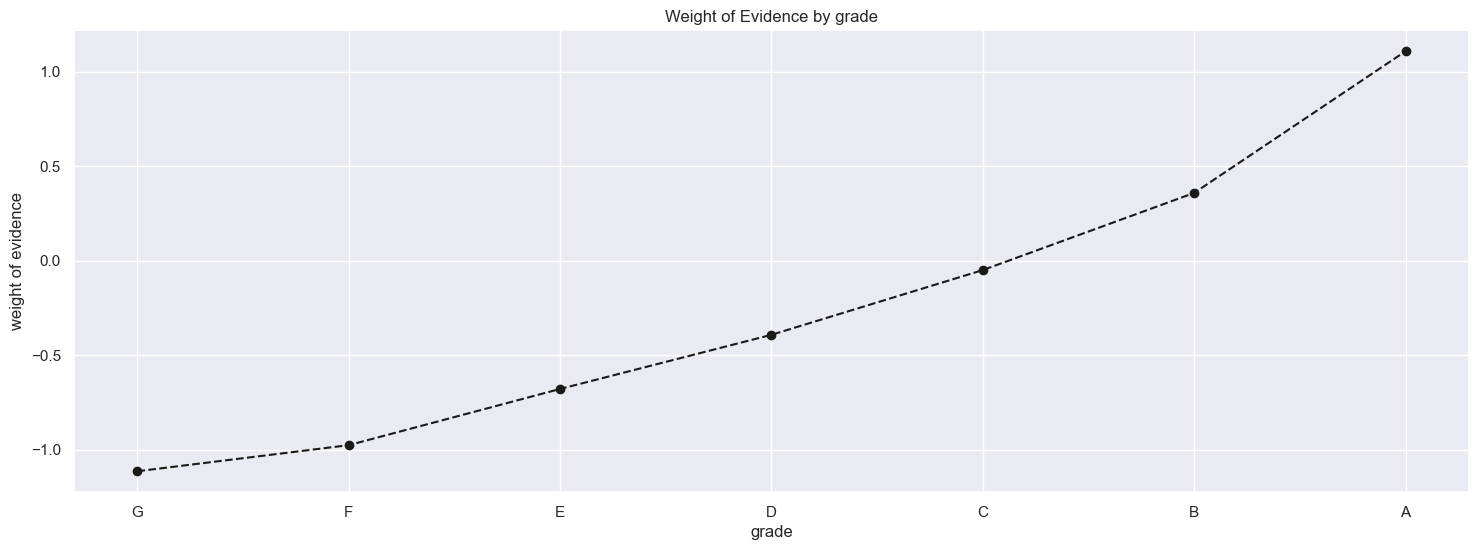

In [89]:
#pass the dataframe into the plot_by_woe function
plot_by_woe(df_temp)

Preprocessing Discrete Variables:Creating Dummy Variable,part1

In [90]:
#pass the column 'home_ownership' and create the woe plot
df_temp = woe_discrete(df_inputs_prepr, 'home_ownership', df_targets_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,OTHER,137,0.795620,0.000367,109.0,28.0,0.000328,0.000687,-0.738602,NaN,NaN,inf
1,NONE,40,0.850000,0.000107,34.0,6.0,0.000102,0.000147,-0.363144,0.054380,0.375458,inf
2,RENT,150599,0.873870,0.403720,131604.0,18995.0,0.396099,0.465815,-0.162123,0.023870,0.201021,inf
3,OWN,33295,0.892536,0.089256,29717.0,3578.0,0.089442,0.087743,0.019170,0.018666,0.181294,inf
4,MORTGAGE,188956,0.903835,0.506546,170785.0,18171.0,0.514026,0.445608,0.142834,0.011298,0.123663,inf
5,ANY,1,1.000000,0.000003,1.0,0.0,0.000003,0.000000,inf,0.096165,inf,inf


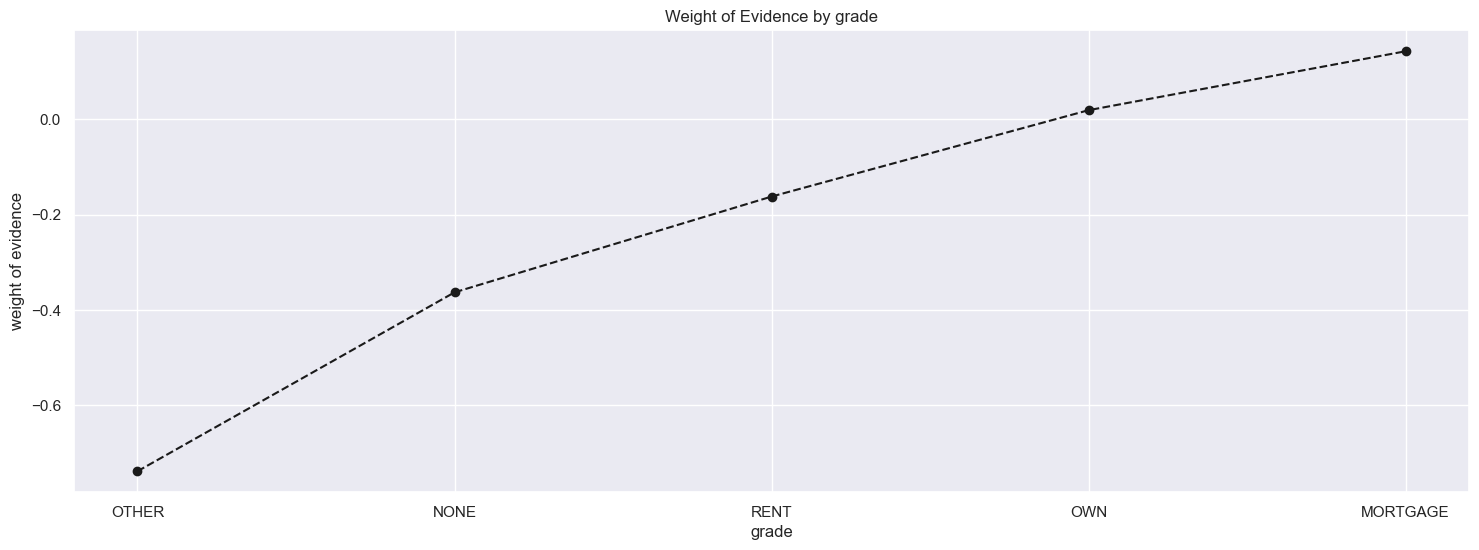

In [91]:
#plot the woe for 'home_ownership'
plot_by_woe(df_temp)

In [92]:
#we will be creating one hot encoding for all these unique values in each column so we will try to minimize the number of unique values by merging the unique values:
#add the binary values of values 'RENT','OTHER','NONE','ANY' as they have similar WoE values
df_inputs_prepr['home_ownership:RENT_OTHER_NONE_ANY'] = sum([df_inputs_prepr['home_ownership:RENT'],df_inputs_prepr['home_ownership:OTHER'],
                                                           df_inputs_prepr['home_ownership:NONE'],df_inputs_prepr['home_ownership:ANY']])
df_inputs_test['home_ownership:RENT_OTHER_NONE_ANY'] = sum([df_inputs_test['home_ownership:RENT'],df_inputs_test['home_ownership:OTHER'],
                                                           df_inputs_test['home_ownership:NONE'],df_inputs_test['home_ownership:ANY']])

PREPROCESSING DISCRETE VARRIABLES:DUMMMY VARRIABLES

In [93]:
#check the unique values in addr_state
df_inputs_prepr['addr_state'].unique()

array(['SC', 'NJ', 'GA', 'MA', 'CA', 'IL', 'NC', 'NY', 'TX', 'CT', 'FL',
       'VA', 'UT', 'AZ', 'MD', 'WI', 'MI', 'CO', 'TN', 'IN', 'AL', 'NV',
       'MT', 'RI', 'OR', 'MN', 'KS', 'AK', 'PA', 'OH', 'WA', 'KY', 'OK',
       'MO', 'NM', 'HI', 'WV', 'LA', 'VT', 'AR', 'DC', 'SD', 'NH', 'WY',
       'MS', 'DE', 'IA', 'NE', 'ID', 'ME'], dtype=object)

In [94]:
#apply the function woe_discrete on 'addr_state'
df_temp = woe_discrete(df_inputs_prepr, 'addr_state', df_targets_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,NE,13,0.461538,0.000035,6.0,7.0,0.000018,0.000172,-2.251896,NaN,NaN,inf
1,IA,13,0.769231,0.000035,10.0,3.0,0.000030,0.000074,-0.893772,0.307692,1.358123,inf
2,NV,5221,0.864585,0.013996,4514.0,707.0,0.013586,0.017338,-0.243837,0.095355,0.649935,inf
3,FL,25211,0.875808,0.067585,22080.0,3131.0,0.066456,0.076782,-0.144425,0.011223,0.099411,inf
4,HI,2001,0.877061,0.005364,1755.0,246.0,0.005282,0.006033,-0.132852,0.001253,0.011573,inf
5,AL,4671,0.877328,0.012522,4098.0,573.0,0.012334,0.014052,-0.130376,0.000267,0.002476,inf
6,NM,2075,0.883373,0.005563,1833.0,242.0,0.005517,0.005935,-0.072973,0.006045,0.057403,inf
7,VA,11366,0.883864,0.030470,10046.0,1320.0,0.030236,0.032370,-0.068202,0.000491,0.004771,inf
8,NY,32211,0.883984,0.086350,28474.0,3737.0,0.085701,0.091643,-0.067037,0.000120,0.001165,inf
9,OK,3284,0.884287,0.008804,2904.0,380.0,0.008740,0.009319,-0.064072,0.000304,0.002965,inf


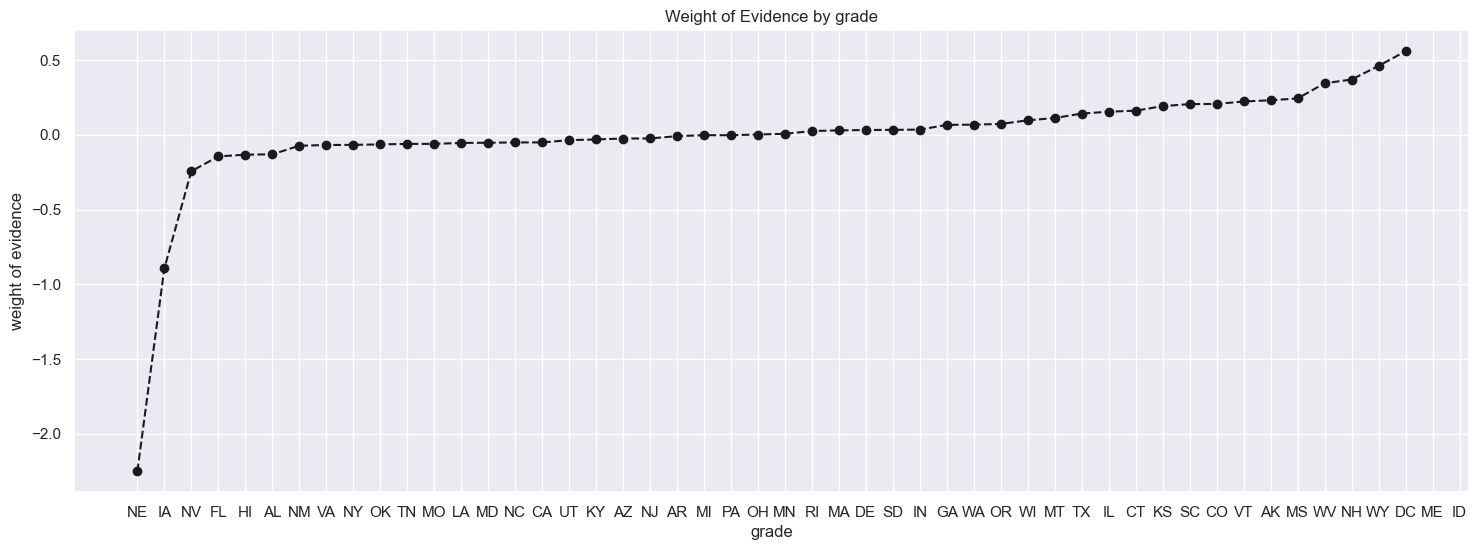

In [95]:
#plot the woe_plot
plot_by_woe(df_temp)

In [96]:
#adding the state 'ND' if it is not present in columns and make it zero if not present
if['addr_state:ND'] in df_inputs_prepr.columns.values:
    pass
else:
    df_inputs_prepr['addr_state:ND']=0
if['addr_state:ND'] in df_inputs_test.columns.values:
    pass
else:
    df_inputs_test['addr_state:ND']=0

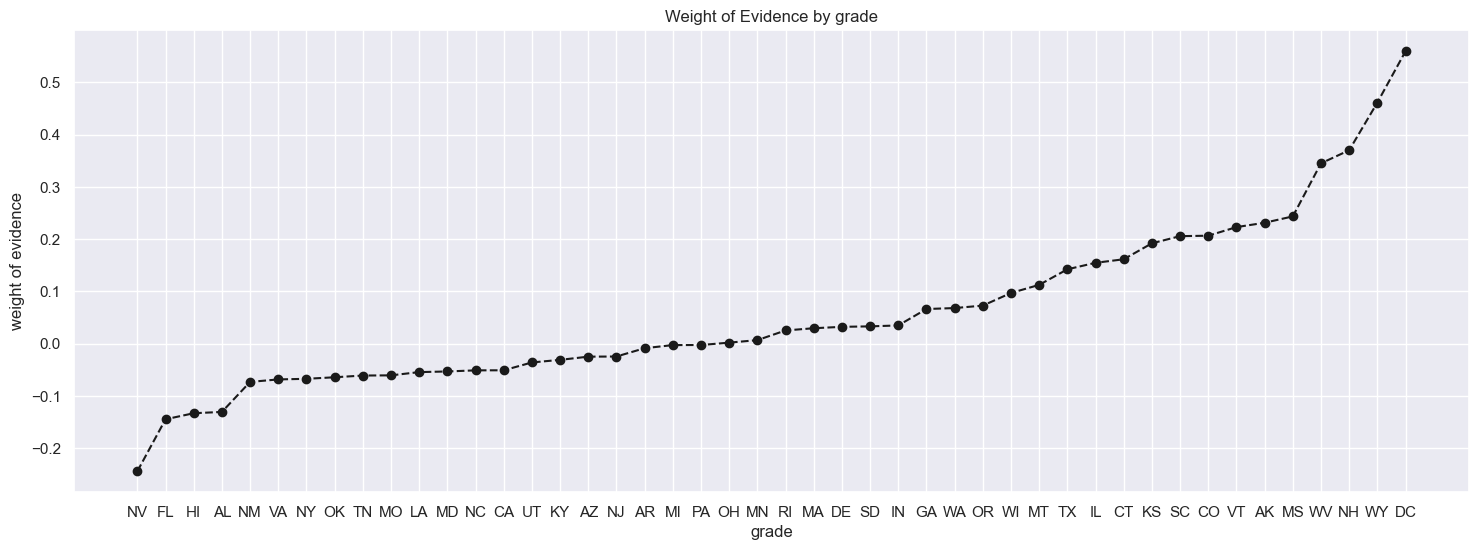

In [97]:
#plot the woe_plot
#Weight of evidence is not calculated for 2 states. There are no bads. The first two states have very few observations. 
#These can be clubbed w/ the next riskiest category
plot_by_woe(df_temp.iloc[2:-2,:])

Nevada has a lower WOE than the states after. It could be clubbed with the low proportion states we had excluded. The state with no records (North Dakota) can be included here. This would be a conservative approach to take. For states with unknown values, assigning them the worst WOE value. The first dummy variable will include NE, IA, NV, FL, HI and AL. The states at the end will include WV, NH, WY, DC, ME and ID. Plotting the remaining states:

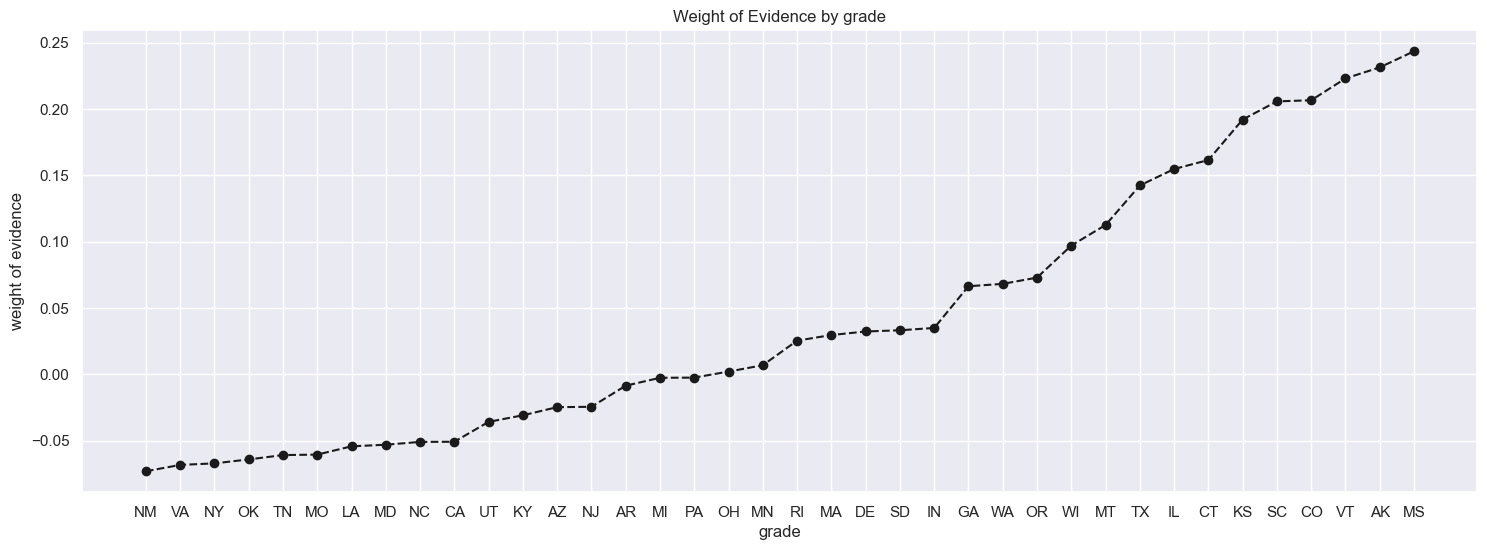

In [98]:
#woe_plot for values whose WoE values differs at large
plot_by_woe(df_temp.iloc[6:-6,:])

In [99]:
##add the binary values of values as they have similar WoE values


df_inputs_prepr['addr_state:ND_NE_IA_NC_FL_HI_AL']=sum([df_inputs_prepr['addr_state:ND'],df_inputs_prepr['addr_state:IA'],
                                                       df_inputs_prepr['addr_state:NE'],df_inputs_prepr['addr_state:NC'],
                                                       df_inputs_prepr['addr_state:FL'],df_inputs_prepr['addr_state:HI'], 
                                                       df_inputs_prepr['addr_state:AL']])

df_inputs_prepr['addr_state:NM_VA']=sum([df_inputs_prepr['addr_state:NM'],df_inputs_prepr['addr_state:VA']])

df_inputs_prepr['addr_state:OK_TN_MO_LA_MD_NC']=sum([df_inputs_prepr['addr_state:OK'],df_inputs_prepr['addr_state:TN'],
                                                       df_inputs_prepr['addr_state:MO'],df_inputs_prepr['addr_state:LA'],
                                                       df_inputs_prepr['addr_state:MD'],df_inputs_prepr['addr_state:NC']])


df_inputs_prepr['addr_state:UT_KY_AZ_NJ']=sum([df_inputs_prepr['addr_state:UT'],df_inputs_prepr['addr_state:KY'],
                                                       df_inputs_prepr['addr_state:AZ'],df_inputs_prepr['addr_state:NJ']])


df_inputs_prepr['addr_state:AR_MI_PA_OH_MN']=sum([df_inputs_prepr['addr_state:AR'],df_inputs_prepr['addr_state:MI'],
                                                       df_inputs_prepr['addr_state:PA'],df_inputs_prepr['addr_state:OH'],
                                                       df_inputs_prepr['addr_state:MN']])

df_inputs_prepr['addr_state:RI_MA_DE_SD_IN']=sum([df_inputs_prepr['addr_state:RI'],df_inputs_prepr['addr_state:MA'],
                                                       df_inputs_prepr['addr_state:DE'],df_inputs_prepr['addr_state:SD'],
                                                       df_inputs_prepr['addr_state:IN']])

df_inputs_prepr['addr_state:GA_WA_OR']=sum([df_inputs_prepr['addr_state:GA'],df_inputs_prepr['addr_state:WA'],
                                                       df_inputs_prepr['addr_state:OR']])

df_inputs_prepr['addr_state:WI_MT']=sum([df_inputs_prepr['addr_state:WI'],df_inputs_prepr['addr_state:MT']])


df_inputs_prepr['addr_state:IL_CT']=sum([df_inputs_prepr['addr_state:IL'],df_inputs_prepr['addr_state:CT']])

df_inputs_prepr['addr_state:KS_SC_CO_VT_AK_MS']=sum([df_inputs_prepr['addr_state:KS'],df_inputs_prepr['addr_state:SC'],
                                                       df_inputs_prepr['addr_state:CO'],df_inputs_prepr['addr_state:VT'],
                                                       df_inputs_prepr['addr_state:AK'],df_inputs_prepr['addr_state:MS']])


df_inputs_prepr['addr_state:WV_NH_WY_DC_ME_ID']=sum([df_inputs_prepr['addr_state:WV'],df_inputs_prepr['addr_state:NH'],
                                                       df_inputs_prepr['addr_state:WY'],df_inputs_prepr['addr_state:DC'],
                                                       df_inputs_prepr['addr_state:ME'],df_inputs_prepr['addr_state:ID']])

In [100]:
df_inputs_test['addr_state:ND_NE_IA_NC_FL_HI_AL']=sum([df_inputs_test['addr_state:ND'],df_inputs_test['addr_state:IA'],
                                                       df_inputs_test['addr_state:NE'],df_inputs_test['addr_state:NC'],
                                                       df_inputs_test['addr_state:FL'],df_inputs_test['addr_state:HI'], 
                                                       df_inputs_test['addr_state:AL']])

df_inputs_test['addr_state:NM_VA']=sum([df_inputs_test['addr_state:NM'],df_inputs_test['addr_state:VA']])

df_inputs_test['addr_state:OK_TN_MO_LA_MD_NC']=sum([df_inputs_test['addr_state:OK'],df_inputs_test['addr_state:TN'],
                                                       df_inputs_test['addr_state:MO'],df_inputs_test['addr_state:LA'],
                                                       df_inputs_test['addr_state:MD'],df_inputs_test['addr_state:NC']])


df_inputs_test['addr_state:UT_KY_AZ_NJ']=sum([df_inputs_test['addr_state:UT'],df_inputs_test['addr_state:KY'],
                                                       df_inputs_test['addr_state:AZ'],df_inputs_test['addr_state:NJ']])


df_inputs_test['addr_state:AR_MI_PA_OH_MN']=sum([df_inputs_test['addr_state:AR'],df_inputs_test['addr_state:MI'],
                                                       df_inputs_test['addr_state:PA'],df_inputs_test['addr_state:OH'],
                                                       df_inputs_test['addr_state:MN']])

df_inputs_test['addr_state:RI_MA_DE_SD_IN']=sum([df_inputs_test['addr_state:RI'],df_inputs_test['addr_state:MA'],
                                                       df_inputs_test['addr_state:DE'],df_inputs_test['addr_state:SD'],
                                                       df_inputs_test['addr_state:IN']])

df_inputs_test['addr_state:GA_WA_OR']=sum([df_inputs_test['addr_state:GA'],df_inputs_test['addr_state:WA'],
                                                       df_inputs_test['addr_state:OR']])

df_inputs_test['addr_state:WI_MT']=sum([df_inputs_test['addr_state:WI'],df_inputs_test['addr_state:MT']])


df_inputs_test['addr_state:IL_CT']=sum([df_inputs_test['addr_state:IL'],df_inputs_test['addr_state:CT']])

df_inputs_test['addr_state:KS_SC_CO_VT_AK_MS']=sum([df_inputs_test['addr_state:KS'],df_inputs_test['addr_state:SC'],
                                                       df_inputs_test['addr_state:CO'],df_inputs_test['addr_state:VT'],
                                                       df_inputs_test['addr_state:AK'],df_inputs_test['addr_state:MS']])


df_inputs_test['addr_state:WV_NH_WY_DC_ME_ID']=sum([df_inputs_test['addr_state:WV'],df_inputs_test['addr_state:NH'],
                                                       df_inputs_test['addr_state:WY'],df_inputs_test['addr_state:DC'],
                                                       df_inputs_test['addr_state:ME'],df_inputs_test['addr_state:ID']])


In [101]:
#check the unique values of verification_status column
df_inputs_prepr['verification_status'].unique()

array(['Source Verified', 'Not Verified', 'Verified'], dtype=object)

In [102]:
#apply the woe_discrete function
df_temp = woe_discrete(df_inputs_prepr, 'verification_status', df_targets_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,Verified,134414,0.872781,0.360332,117314.0,17100.0,0.353090,0.419344,-0.171969,NaN,NaN,0.020384
1,Source Verified,120030,0.895918,0.321772,107537.0,12493.0,0.323663,0.306366,0.054922,0.023137,0.226891,0.020384
2,Not Verified,118584,0.905679,0.317896,107399.0,11185.0,0.323248,0.274290,0.164232,0.009761,0.109311,0.020384


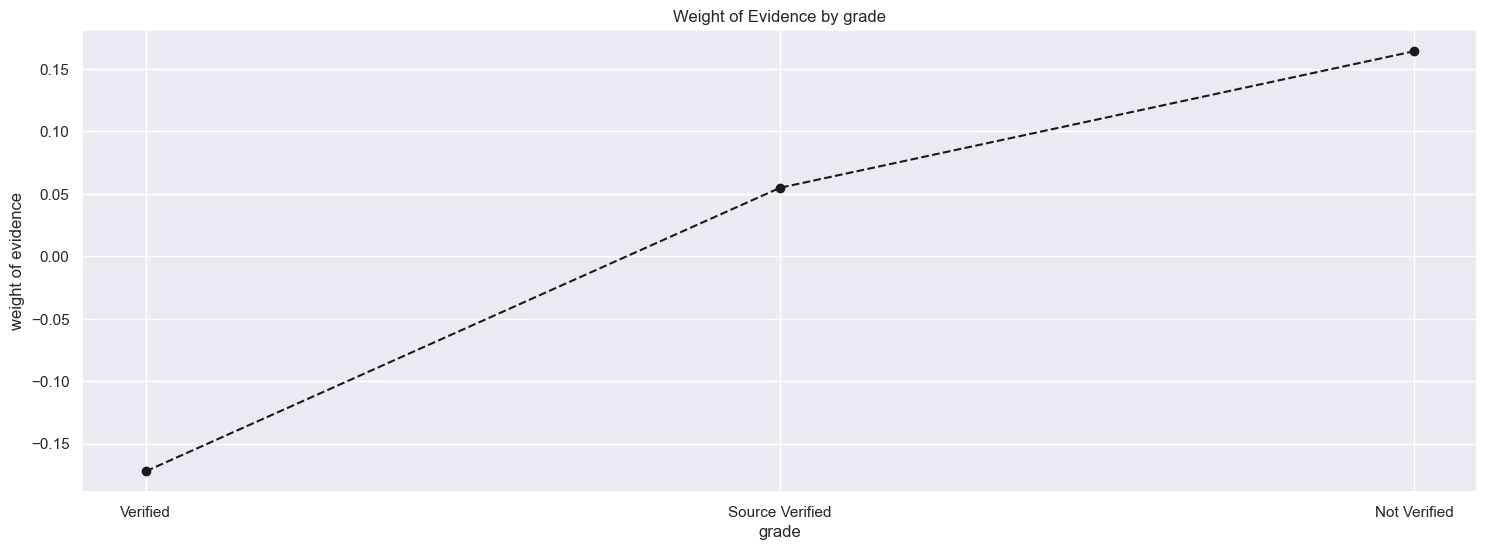

In [103]:
#plot the woe plot
plot_by_woe(df_temp)

In [104]:
#check the unique values of 'purpose'
df_inputs_prepr['purpose'].unique()

array(['debt_consolidation', 'educational', 'other', 'home_improvement',
       'credit_card', 'major_purchase', 'wedding', 'small_business',
       'vacation', 'house', 'car', 'moving', 'renewable_energy',
       'medical'], dtype=object)

In [105]:
#apply the woe_discrete on 'purpose'
df_temp = woe_discrete(df_inputs_prepr, 'purpose', df_targets_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,small_business,5582,0.786098,0.014964,4388.0,1194.0,0.013207,0.029280,-0.796180,NaN,NaN,0.035418
1,educational,333,0.801802,0.000893,267.0,66.0,0.000804,0.001619,-0.700151,0.015704,0.096029,0.035418
2,moving,2392,0.839465,0.006412,2008.0,384.0,0.006044,0.009417,-0.443493,0.037663,0.256658,0.035418
3,house,1830,0.860109,0.004906,1574.0,256.0,0.004737,0.006278,-0.281547,0.020644,0.161946,0.035418
4,other,18884,0.862264,0.050624,16283.0,2601.0,0.049008,0.063784,-0.263519,0.002155,0.018028,0.035418
5,renewable_energy,281,0.864769,0.000753,243.0,38.0,0.000731,0.000932,-0.242270,0.002504,0.021250,0.035418
6,medical,3684,0.868350,0.009876,3199.0,485.0,0.009628,0.011894,-0.211300,0.003581,0.030969,0.035418
7,wedding,1887,0.881823,0.005059,1664.0,223.0,0.005008,0.005469,-0.087937,0.013473,0.123363,0.035418
8,vacation,1991,0.882471,0.005337,1757.0,234.0,0.005288,0.005738,-0.081703,0.000648,0.006234,0.035418
9,debt_consolidation,219183,0.886884,0.587578,194390.0,24793.0,0.585071,0.607999,-0.038440,0.004413,0.043263,0.035418


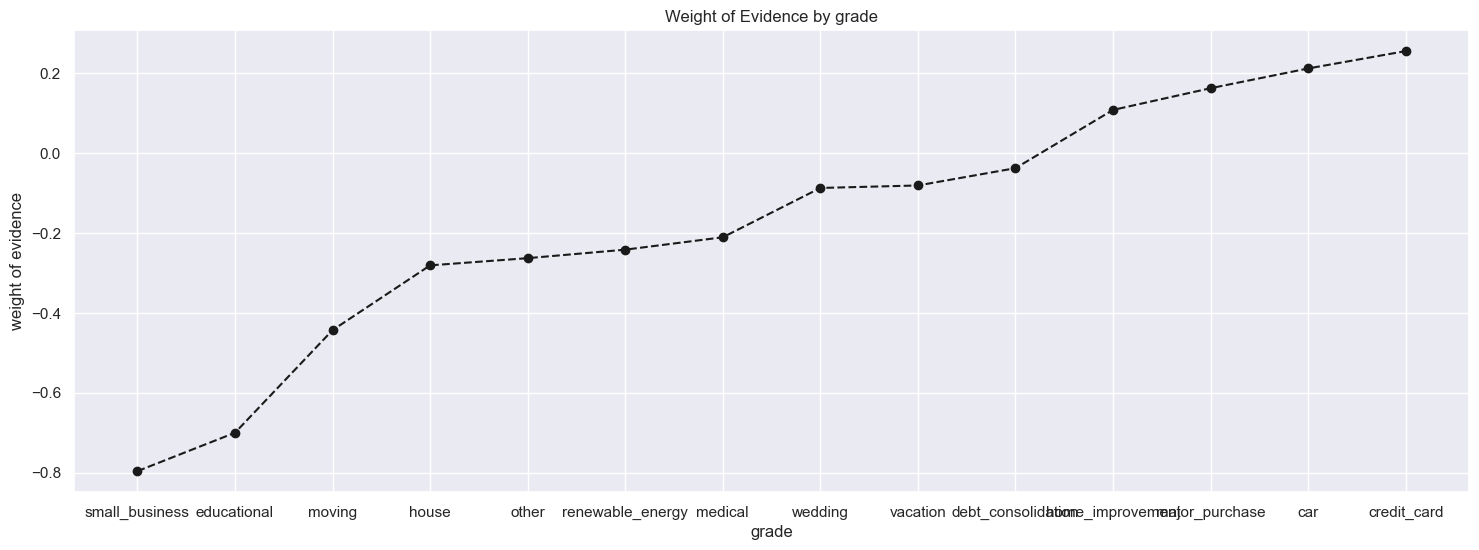

In [106]:
#plot the woe plot
plot_by_woe(df_temp)

In [107]:
#make all the similar woe values in one column

df_inputs_prepr['purpose:educ_sm_b_wedd_ren_en_mov_house']=sum([df_inputs_prepr['purpose:small_business'],df_inputs_prepr['purpose:educational'],
                                                               df_inputs_prepr['purpose:renewable_energy'],df_inputs_prepr['purpose:moving'],
                                  -                              df_inputs_prepr['purpose:house'],df_inputs_prepr['purpose:other'],
                                                               df_inputs_prepr['purpose:medical'],df_inputs_prepr['purpose:wedding'],
                                                               df_inputs_prepr['purpose:vacation'],df_inputs_prepr['purpose:debt_consolidation'],
                                                               df_inputs_prepr['purpose:home_improvement'],df_inputs_prepr['purpose:major_purchase'],
                                                               df_inputs_prepr['purpose:car'],df_inputs_prepr['purpose:credit_card']])

In [108]:
df_inputs_test['purpose:educ_sm_b_wedd_ren_en_mov_house']=sum([df_inputs_test['purpose:small_business'],df_inputs_test['purpose:educational'],
                                                               df_inputs_test['purpose:renewable_energy'],df_inputs_test['purpose:moving'],
                                  -                              df_inputs_test['purpose:house'],df_inputs_test['purpose:other'],
                                                               df_inputs_test['purpose:medical'],df_inputs_test['purpose:wedding'],
                                                               df_inputs_test['purpose:vacation'],df_inputs_test['purpose:debt_consolidation'],
                                                               df_inputs_test['purpose:home_improvement'],df_inputs_test['purpose:major_purchase'],
                                                               df_inputs_test['purpose:car'],df_inputs_test['purpose:credit_card']])


In [109]:
#check the 'initial_list_status' unique values
df_inputs_prepr['initial_list_status'].unique()

array(['f', 'w'], dtype=object)

In [110]:
#apply the woe_discrete function
df_temp = woe_discrete(df_inputs_prepr, 'initial_list_status', df_targets_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,f,242514,0.879694,0.650123,213338.0,29176.0,0.642101,0.715484,-0.108214,NaN,NaN,0.02478
1,w,130514,0.911105,0.349877,118912.0,11602.0,0.357899,0.284516,0.229461,0.031412,0.337675,0.02478


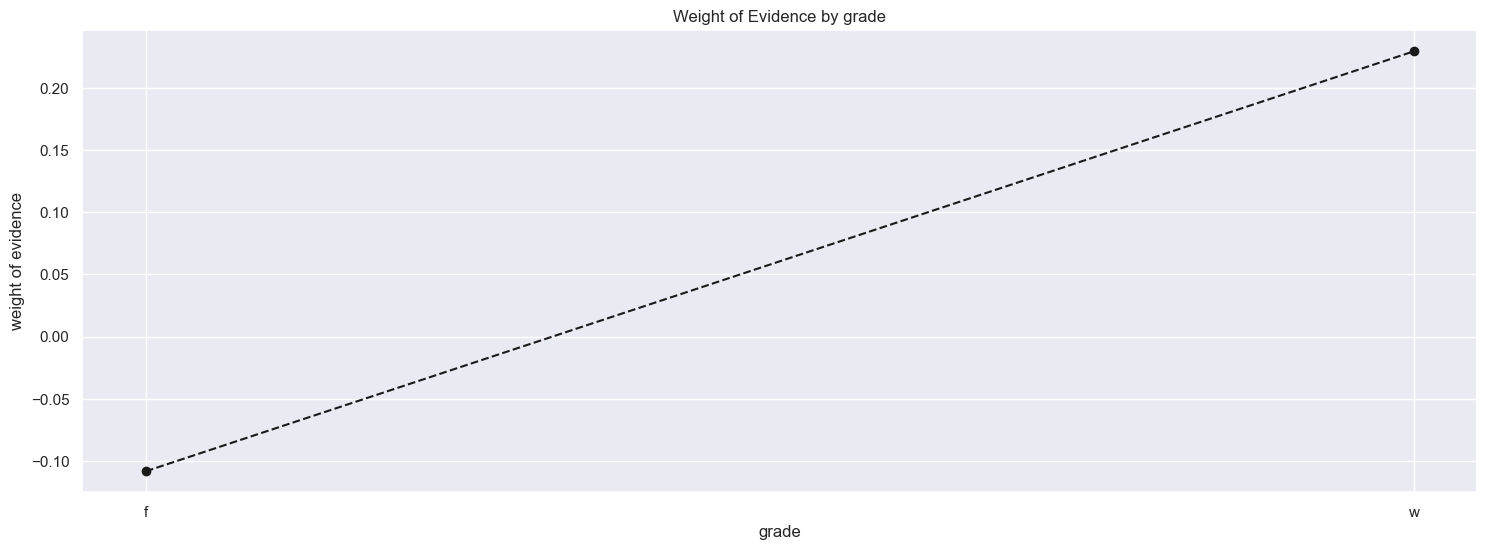

In [111]:
#plot the woe plot
plot_by_woe(df_temp)

PREPROCESSING CONTINUOUS VARIABLES:AUTOMATING CALCULATIONS AND VISUALIZING RESULTS

In [112]:
#Earlier we defined a function for categorical values

#Now, this is the function for preprocessing of continuous variables

def woe_continuous(df,discrete_variable_name,good_bad_variable_df):
    df = pd.concat([df[discrete_variable_name],good_bad_variable_df], axis=1)
    df = pd.concat([df.groupby(df.columns.values[0],as_index = False)[df.columns.values[1]].count(),
                   df.groupby(df.columns.values[0],as_index = False)[df.columns.values[1]].mean()],axis=1)
    df= df.iloc[:,[0,1,3]]
    df.columns=[df1.columns.values[0],'n_obs','prop_good']
    df['prop_n_obs']=df['n_obs']/df['n_obs'].sum()
    df['n_good']=df['prop_good']*df['n_obs']
    df['n_bad']=(1-df['prop_good'])*df['n_obs']
    df['prop_n_good']=df['n_good']/df['n_good'].sum()
    df['prop_n_bad']=df['n_bad']/df['n_bad'].sum()
    df['WoE']=np.log(df['prop_n_good']/df['prop_n_bad'])
    df['diff_prop_good'] = df['prop_good'].diff().abs()
    df['diff_WoE']=df['WoE'].diff().abs()
    df['IV'] = (df['prop_n_good'] - df['prop_n_bad'])*df['WoE']
    df['IV']=df['IV'].sum()
    return df

PREPROCESSING CONTNUOUS VARIABLES:CREATING DUMMY VARIABLES

In [113]:
#check the 'term_int' unique values
df_inputs_prepr['term_int'].unique()

array([36, 60])

In [114]:
#apply the woe_continuous function
df_temp = woe_continuous(df_inputs_prepr, 'term_int', df_targets_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,36,270419,0.902995,0.724929,244187.0,26232.0,0.73495,0.643288,0.133209,NaN,NaN,0.039434
1,60,102609,0.858239,0.275071,88063.0,14546.0,0.26505,0.356712,-0.297009,0.044756,0.430218,0.039434


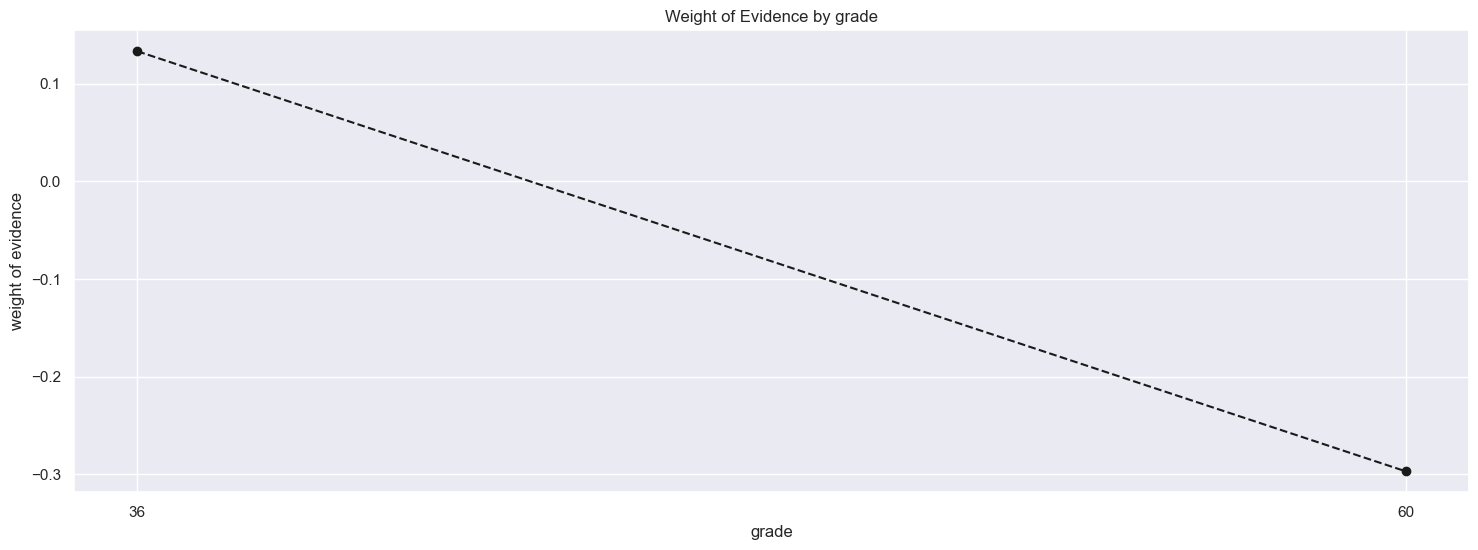

In [115]:
#plot the woe plot
plot_by_woe(df_temp)

In [116]:
#Convert it into binary encoded format by putting 1 and 0 inplace

df_inputs_prepr['term:36']=np.where((df_inputs_prepr['term_int'] ==36),1,0)
df_inputs_prepr['term:60']=np.where((df_inputs_prepr['term_int']==60),1,0)
df_inputs_test['term:36']=np.where((df_inputs_test['term_int'] ==36),1,0)
df_inputs_test['term:60']=np.where((df_inputs_test['term_int']==60),1,0)

In [117]:
#check the unique values of 'emp_length_int' column
df_inputs_prepr['emp_length_int'].unique()

array([ 3,  6, 10,  7,  5,  0,  2,  9,  1,  8,  4])

In [118]:
#apply the woe_continuous function
df_temp = woe_continuous(df_inputs_prepr, 'emp_length_int', df_targets_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0,45720,0.876400,0.122565,40069.0,5651.0,0.120599,0.138580,-0.138975,NaN,NaN,0.006506
1,1,23654,0.886996,0.063411,20981.0,2673.0,0.063148,0.065550,-0.037329,0.010596,0.101645,0.006506
2,2,33078,0.890955,0.088674,29471.0,3607.0,0.088701,0.088455,0.002785,0.003959,0.040114,0.006506
3,3,29205,0.890772,0.078292,26015.0,3190.0,0.078299,0.078228,0.000907,0.000183,0.001878,0.006506
4,4,22468,0.890644,0.060231,20011.0,2457.0,0.060229,0.060253,-0.000404,0.000128,0.001311,0.006506
5,5,24602,0.884725,0.065952,21766.0,2836.0,0.065511,0.069547,-0.059790,0.005920,0.059387,0.006506
6,6,20887,0.883899,0.055993,18462.0,2425.0,0.055567,0.059468,-0.067862,0.000826,0.008071,0.006506
7,7,21049,0.887453,0.056427,18680.0,2369.0,0.056223,0.058095,-0.032759,0.003554,0.035102,0.006506
8,8,17853,0.889878,0.047860,15887.0,1966.0,0.047816,0.048212,-0.008245,0.002425,0.024515,0.006506
9,9,14267,0.886662,0.038246,12650.0,1617.0,0.038074,0.039654,-0.040660,0.003217,0.032416,0.006506


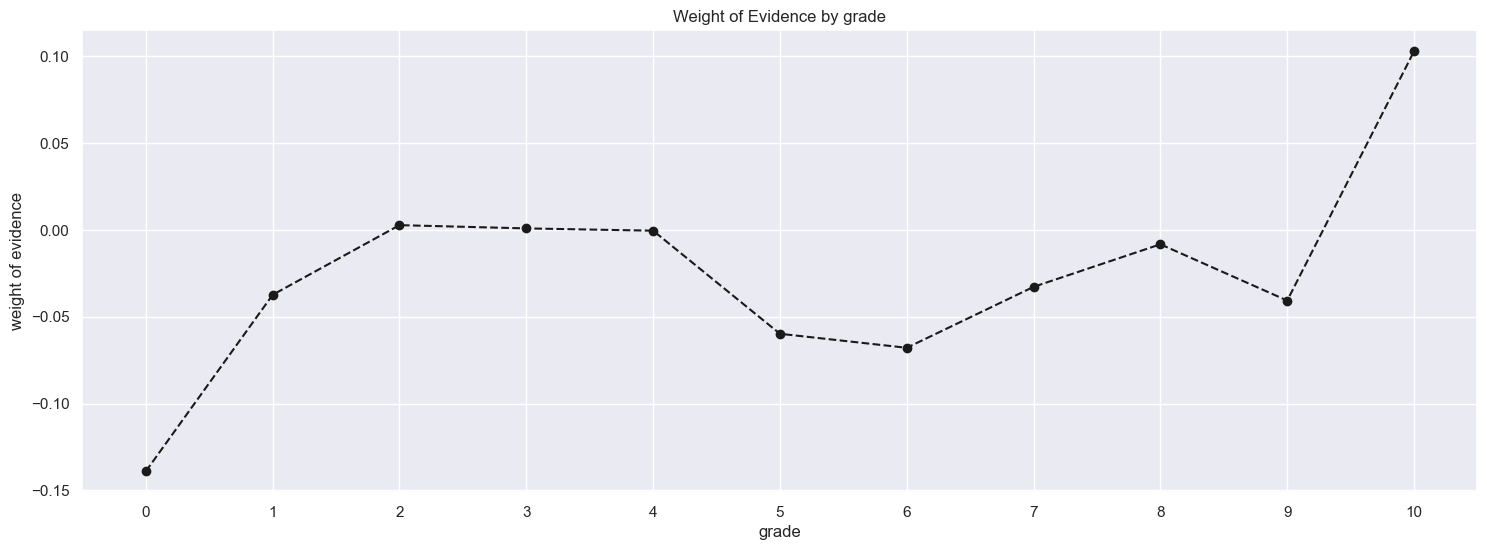

In [119]:
#plot the woe plot
plot_by_woe(df_temp)

In [120]:
##Convert it into binary encoded format by putting 1 and 0 inplace for WoE values that are close to each other

df_inputs_prepr['emp_length:0']=np.where(df_inputs_prepr['emp_length_int'].isin([0]),1,0)
df_inputs_prepr['emp_length:1']=np.where(df_inputs_prepr['emp_length_int'].isin([1]),1,0)
df_inputs_prepr['emp_length:2-4']=np.where(df_inputs_prepr['emp_length_int'].isin(range(2,5)),1,0)
df_inputs_prepr['emp_length:5-6']=np.where(df_inputs_prepr['emp_length_int'].isin(range(5,7)),1,0)
df_inputs_prepr['emp_length:7-9']=np.where(df_inputs_prepr['emp_length_int'].isin(range(7,10)),1,0)
df_inputs_prepr['emp_length:10']=np.where(df_inputs_prepr['emp_length_int'].isin([10]),1,0)

In [121]:
df_inputs_test['emp_length:0']=np.where(df_inputs_test['emp_length_int'].isin([0]),1,0)
df_inputs_test['emp_length:1']=np.where(df_inputs_test['emp_length_int'].isin([1]),1,0)
df_inputs_test['emp_length:2-4']=np.where(df_inputs_test['emp_length_int'].isin(range(2,5)),1,0)
df_inputs_test['emp_length:5-6']=np.where(df_inputs_test['emp_length_int'].isin(range(5,7)),1,0)
df_inputs_test['emp_length:7-9']=np.where(df_inputs_test['emp_length_int'].isin(range(7,10)),1,0)
df_inputs_test['emp_length:10']=np.where(df_inputs_test['emp_length_int'].isin([10]),1,0)

In [122]:
#check the unique values in 'mths_since_issued_date' column
df_inputs_prepr['mths_since_issued_date'].unique()

array([126., 145., 135., 125., 183., 118., 172., 134., 123., 138., 139.,
       124., 121., 132., 140., 195., 131., 143., 130., 128., 129., 122.,
       119., 147., 150., 168., 127., 157., 144., 120., 142., 170., 146.,
       137., 160., 149., 133., 141., 154., 155., 151., 169., 162., 163.,
       136., 185., 164., 153., 166., 117., 152., 173., 158., 148., 165.,
       167., 171., 198., 174., 176., 159., 156., 161., 178., 175., 180.,
       186., 207., 187., 200., 192., 201., 196., 184., 188., 182., 204.,
       203., 190., 199., 202., 206., 181., 197., 194., 191., 205., 189.,
       208., 193.])

In [123]:
#apply the cut function defined in pandas so that we get a range divided values for continous variable

df_inputs_prepr['mths_since_issued_date_factor']=pd.cut(df_inputs_prepr['mths_since_issued_date'],50)
df_inputs_test['mths_since_issued_date_factor']=pd.cut(df_inputs_test['mths_since_issued_date'],50)

In [124]:
#check how the buckets are divided
df_inputs_prepr['mths_since_issued_date_factor']

427211      (124.28, 126.1]
206088      (144.3, 146.12]
136020      (133.38, 135.2]
412305      (124.28, 126.1]
36159      (182.52, 184.34]
                ...        
259178    (116.909, 118.82]
365838     (122.46, 124.28]
131932      (133.38, 135.2]
146867      (135.2, 137.02]
121958      (133.38, 135.2]
Name: mths_since_issued_date_factor, Length: 373028, dtype: category
Categories (50, interval[float64, right]): [(116.909, 118.82] < (118.82, 120.64] < (120.64, 122.46] < (122.46, 124.28] ... (200.72, 202.54] < (202.54, 204.36] < (204.36, 206.18] < (206.18, 208.0]]

In [125]:
#apply the woe_continuous function
df_temp=woe_continuous(df_inputs_prepr,'mths_since_issued_date_factor',df_targets_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(116.909, 118.82]",28170,0.942244,0.075517,26543.0,1627.0,0.079889,0.039899,0.694283,NaN,NaN,0.113131
1,"(118.82, 120.64]",39636,0.928424,0.106255,36799.0,2837.0,0.110757,0.069572,0.464979,0.013820,0.229305,0.113131
2,"(120.64, 122.46]",38614,0.917284,0.103515,35420.0,3194.0,0.106606,0.078327,0.308258,0.011140,0.156721,0.113131
3,"(122.46, 124.28]",29038,0.908603,0.077844,26384.0,2654.0,0.079410,0.065084,0.198945,0.008681,0.109313,0.113131
4,"(124.28, 126.1]",28367,0.901787,0.076045,25581.0,2786.0,0.076993,0.068321,0.119498,0.006815,0.079447,0.113131
5,"(126.1, 127.92]",12165,0.899301,0.032611,10940.0,1225.0,0.032927,0.030041,0.091740,0.002486,0.027758,0.113131
6,"(127.92, 129.74]",24451,0.898900,0.065547,21979.0,2472.0,0.066152,0.060621,0.087315,0.000401,0.004425,0.113131
7,"(129.74, 131.56]",22969,0.888328,0.061574,20404.0,2565.0,0.061412,0.062902,-0.023972,0.010572,0.111287,0.113131
8,"(131.56, 133.38]",20640,0.880523,0.055331,18174.0,2466.0,0.054700,0.060474,-0.100350,0.007804,0.076378,0.113131
9,"(133.38, 135.2]",18312,0.866863,0.049090,15874.0,2438.0,0.047777,0.059787,-0.224240,0.013660,0.123890,0.113131


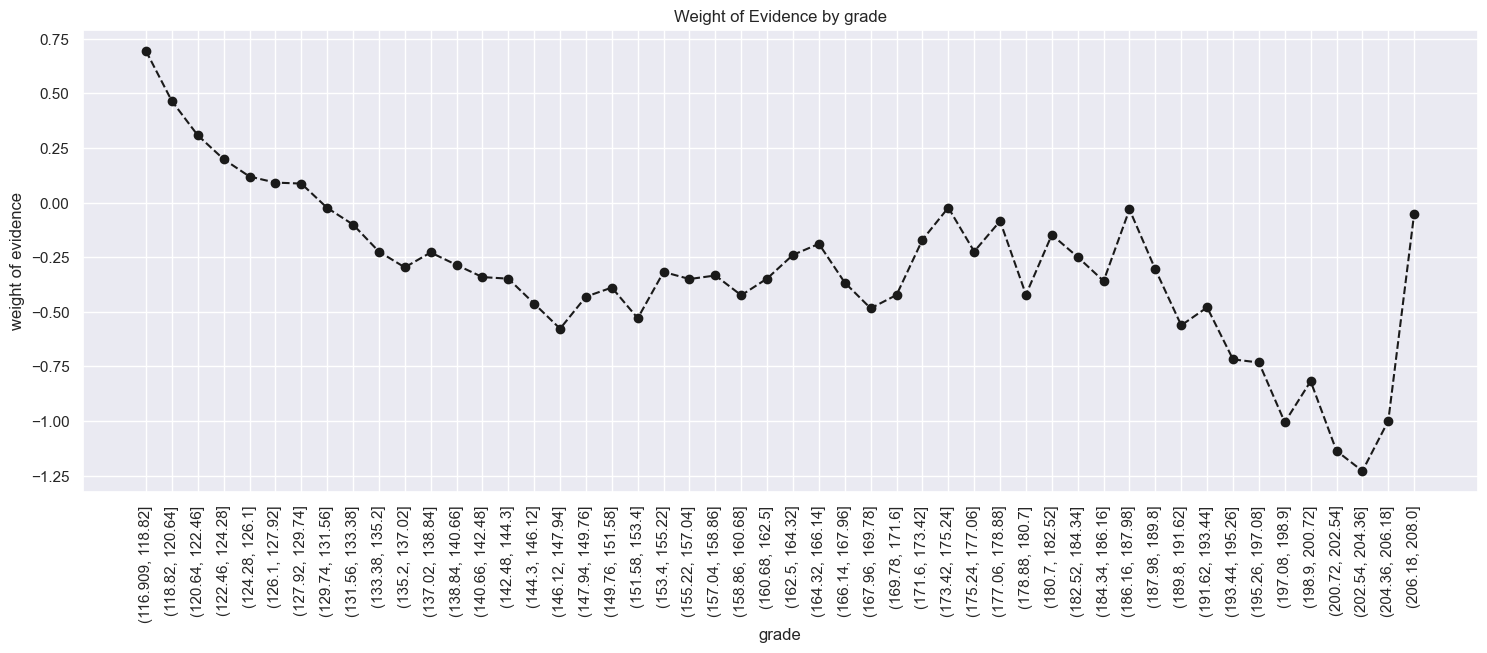

In [126]:
#plot the woe plot
plot_by_woe(df_temp,90)

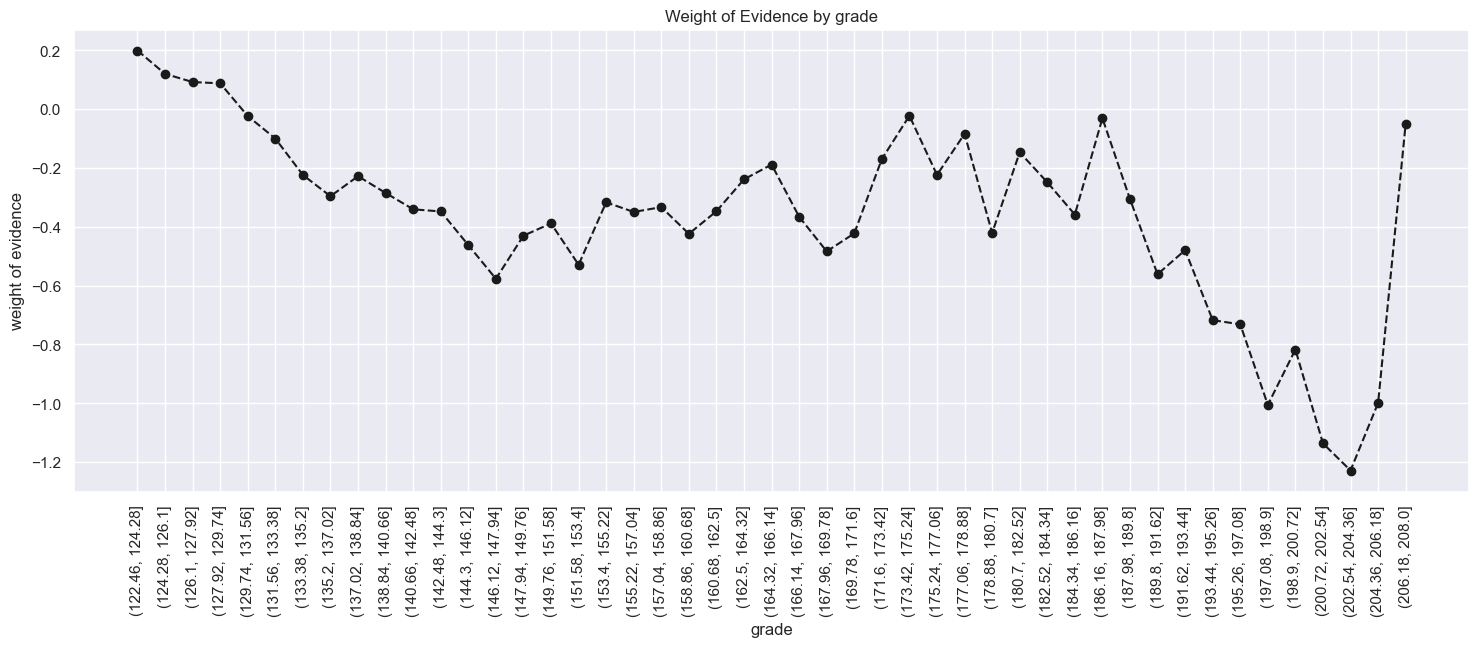

In [127]:
#more variation of woe plot
plot_by_woe(df_temp.iloc[3:,:],90)

In [128]:
###Convert it into binary encoded format by putting 1 and 0 inplace for WoE values that are close to each other

df_inputs_prepr['mths_since_issued_date:<120']=np.where(df_inputs_prepr['mths_since_issued_date'].isin(range(120)),1,0)
df_inputs_prepr['mths_since_issued_date:120-124']=np.where(df_inputs_prepr['mths_since_issued_date'].isin(range(120,125)),1,0)
df_inputs_prepr['mths_since_issued_date:124-128']=np.where(df_inputs_prepr['mths_since_issued_date'].isin(range(124,129)),1,0)
df_inputs_prepr['mths_since_issued_date:128-135']=np.where(df_inputs_prepr['mths_since_issued_date'].isin(range(128,136)),1,0)
df_inputs_prepr['mths_since_issued_date:135-140']=np.where(df_inputs_prepr['mths_since_issued_date'].isin(range(135,141)),1,0)
df_inputs_prepr['mths_since_issued_date:140-145']=np.where(df_inputs_prepr['mths_since_issued_date'].isin(range(140,146)),1,0)
df_inputs_prepr['mths_since_issued_date:145-165']=np.where(df_inputs_prepr['mths_since_issued_date'].isin(range(145,166)),1,0)
df_inputs_prepr['mths_since_issued_date:>165']=np.where(df_inputs_prepr['mths_since_issued_date'].isin(range(166,int(df_inputs_prepr['mths_since_issued_date'].max()))),1,0)

In [129]:
df_inputs_test['mths_since_issued_date:<120']=np.where(df_inputs_test['mths_since_issued_date'].isin(range(120)),1,0)
df_inputs_test['mths_since_issued_date:120-124']=np.where(df_inputs_test['mths_since_issued_date'].isin(range(120,125)),1,0)
df_inputs_test['mths_since_issued_date:124-128']=np.where(df_inputs_test['mths_since_issued_date'].isin(range(124,129)),1,0)
df_inputs_test['mths_since_issued_date:128-135']=np.where(df_inputs_test['mths_since_issued_date'].isin(range(128,136)),1,0)
df_inputs_test['mths_since_issued_date:135-140']=np.where(df_inputs_test['mths_since_issued_date'].isin(range(135,141)),1,0)
df_inputs_test['mths_since_issued_date:140-145']=np.where(df_inputs_test['mths_since_issued_date'].isin(range(140,146)),1,0)
df_inputs_test['mths_since_issued_date:145-165']=np.where(df_inputs_test['mths_since_issued_date'].isin(range(145,166)),1,0)
df_inputs_test['mths_since_issued_date:>165']=np.where(df_inputs_test['mths_since_issued_date'].isin(range(166,int(df_inputs_test['mths_since_issued_date'].max()))),1,0)

In [130]:
#apply the cut function on 'int_rate'
df_inputs_prepr['int_rate_factor']=pd.cut(df_inputs_prepr['int_rate'],50)
df_inputs_test['int_rate_factor']=pd.cut(df_inputs_test['int_rate'],50)

In [131]:
#apply the woe_continuos function
df_temp=woe_continuous(df_inputs_prepr,'int_rate_factor',df_targets_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(5.399, 5.833]",785,0.961783,0.002104,755.0,30.0,0.002272,0.000736,1.127775,NaN,NaN,0.343349
1,"(5.833, 6.246]",8459,0.980376,0.022677,8293.0,166.0,0.024960,0.004071,1.813434,0.018592,0.685659,0.343349
2,"(6.246, 6.658]",7826,0.971505,0.020980,7603.0,223.0,0.022883,0.005469,1.431381,0.008871,0.382053,0.343349
3,"(6.658, 7.071]",1816,0.973018,0.004868,1767.0,49.0,0.005318,0.001202,1.487473,0.001512,0.056092,0.343349
4,"(7.071, 7.484]",3143,0.976456,0.008426,3069.0,74.0,0.009237,0.001815,1.627297,0.003438,0.139824,0.343349
5,"(7.484, 7.897]",12581,0.962324,0.033727,12107.0,474.0,0.036439,0.011624,1.142587,0.014131,0.484710,0.343349
6,"(7.897, 8.31]",9687,0.949314,0.025969,9196.0,491.0,0.027678,0.012041,0.832335,0.013011,0.310252,0.343349
7,"(8.31, 8.722]",6594,0.965271,0.017677,6365.0,229.0,0.019157,0.005616,1.227103,0.015958,0.394768,0.343349
8,"(8.722, 9.135]",9539,0.937415,0.025572,8942.0,597.0,0.026913,0.014640,0.608852,0.027857,0.618250,0.343349
9,"(9.135, 9.548]",6681,0.963928,0.017910,6440.0,241.0,0.019383,0.005910,1.187742,0.026513,0.578889,0.343349


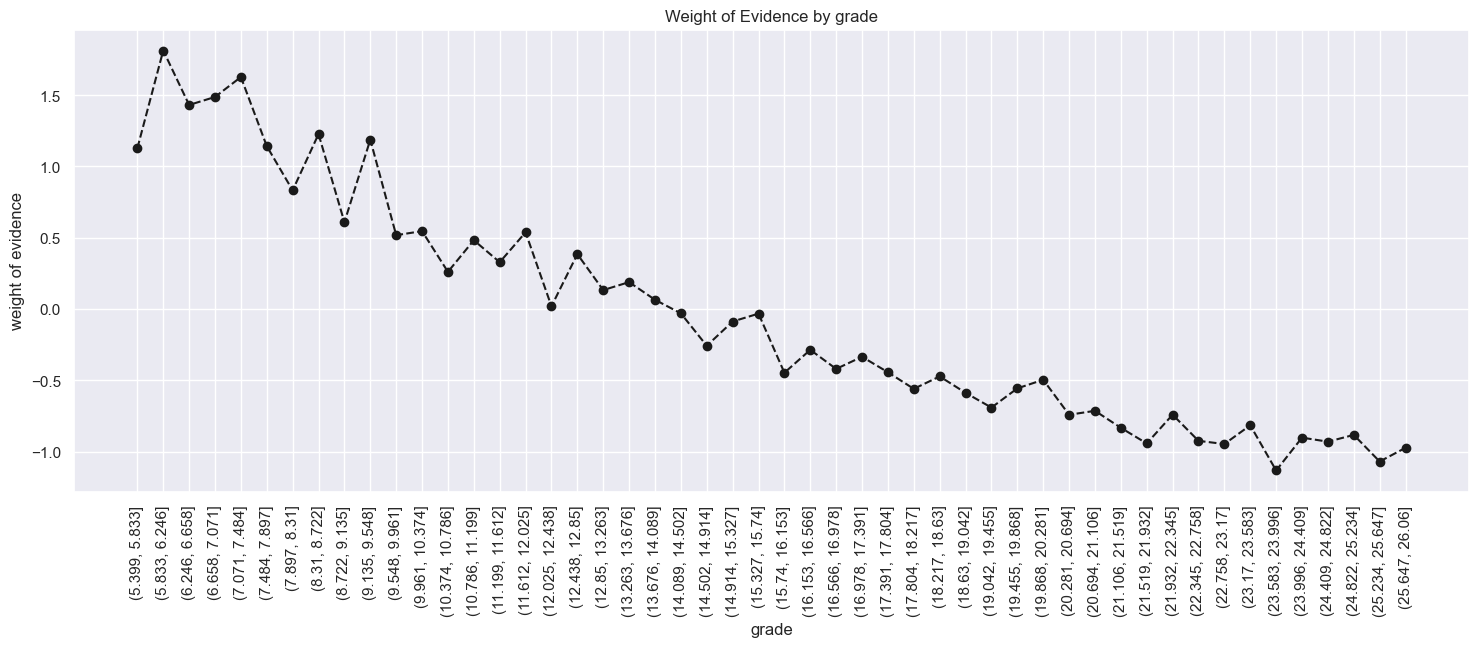

In [132]:
#plot the woe plot
plot_by_woe(df_temp,90)

In [133]:
###Convert it into binary encoded format by putting 1 and 0 inplace for WoE values that are close to each other

df_inputs_prepr['int_rate:<9.548']=np.where((df_inputs_prepr['int_rate']<= 9.548),1,0)
df_inputs_prepr['int_rate:9.548-12.025']=np.where((df_inputs_prepr['int_rate']>9.548)&(df_inputs_prepr['int_rate']<=12.025),1,0)
df_inputs_prepr['int_rate:12.025-15.74']=np.where((df_inputs_prepr['int_rate']>12.025)&(df_inputs_prepr['int_rate']<=15.74),1,0)
df_inputs_prepr['int_rate:15.74-20.281']=np.where((df_inputs_prepr['int_rate']>15.74)&(df_inputs_prepr['int_rate']<=20.281),1,0)
df_inputs_prepr['int_rate:20.281']=np.where((df_inputs_prepr['int_rate']>20.281),1,0)

df_inputs_test['int_rate:<9.548']=np.where((df_inputs_test['int_rate']<= 9.548),1,0)
df_inputs_test['int_rate:9.548-12.025']=np.where((df_inputs_test['int_rate']>9.548)&(df_inputs_test['int_rate']<=12.025),1,0)
df_inputs_test['int_rate:12.025-15.74']=np.where((df_inputs_test['int_rate']>12.025)&(df_inputs_test['int_rate']<=15.74),1,0)
df_inputs_test['int_rate:15.74-20.281']=np.where((df_inputs_test['int_rate']>15.74)&(df_inputs_test['int_rate']<=20.281),1,0)
df_inputs_test['int_rate:20.281']=np.where((df_inputs_test['int_rate']>20.281),1,0)

# **We will be repeating the similar steps for all continuous variables:**

**1.Apply the cut function if unique values are many**

**2.apply the woe_continuos function**

**3.plot the woe_plot**

**4.Convert it into binary encoded format by putting 1 and 0 inplace for WoE values that are close to each other**

In [134]:
#preprocessing of 'funded_amnt_factor'

df_inputs_prepr['funded_amnt_factor']=pd.cut(df_inputs_prepr['funded_amnt'],50)
df_inputs_test['funded_amnt_factor']=pd.cut(df_inputs_test['funded_amnt'],50)
df_temp=woe_continuous(df_inputs_prepr,'funded_amnt_factor',df_targets_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(465.5, 1190.0]",1224,0.905229,0.003281,1108.0,116.0,0.003335,0.002845,0.158977,NaN,NaN,0.014139
1,"(1190.0, 1880.0]",3028,0.903897,0.008117,2737.0,291.0,0.008238,0.007136,0.143549,0.001332,0.015427,0.014139
2,"(1880.0, 2570.0]",6018,0.893819,0.016133,5379.0,639.0,0.016190,0.015670,0.032608,0.010078,0.110941,0.014139
3,"(2570.0, 3260.0]",7248,0.889073,0.019430,6444.0,804.0,0.019395,0.019717,-0.016440,0.004746,0.049048,0.014139
4,"(3260.0, 3950.0]",4751,0.891602,0.012736,4236.0,515.0,0.012749,0.012629,0.009463,0.002529,0.025902,0.014139
5,"(3950.0, 4640.0]",9023,0.890945,0.024189,8039.0,984.0,0.024196,0.024131,0.002689,0.000656,0.006774,0.014139
6,"(4640.0, 5330.0]",15903,0.892159,0.042632,14188.0,1715.0,0.042703,0.042057,0.015238,0.001213,0.012549,0.014139
7,"(5330.0, 6020.0]",17236,0.906069,0.046206,15617.0,1619.0,0.047004,0.039703,0.168806,0.013910,0.153568,0.014139
8,"(6020.0, 6710.0]",6914,0.887619,0.018535,6137.0,777.0,0.018471,0.019054,-0.031094,0.018449,0.199900,0.014139
9,"(6710.0, 7400.0]",11806,0.898018,0.031649,10602.0,1204.0,0.031910,0.029526,0.077648,0.010399,0.108742,0.014139


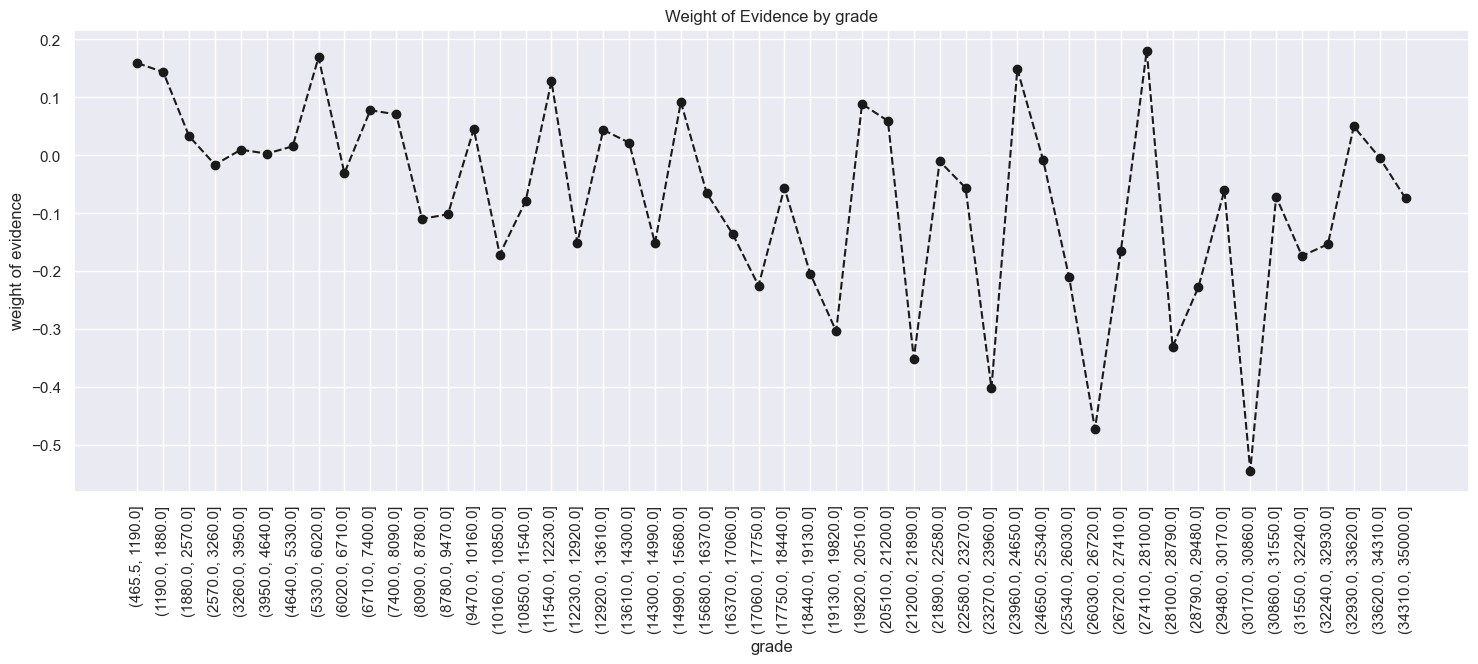

In [135]:
#plot the woe_plot
plot_by_woe(df_temp,90)

In [136]:
#convert the 'mths_since_earliest_cr_line' to float
df_inputs_prepr['mths_since_earliest_cr_line']= df_inputs_prepr['mths_since_earliest_cr_line'].astype(float)
df_inputs_test['mths_since_earliest_cr_line']= df_inputs_test['mths_since_earliest_cr_line'].astype(float)

In [137]:
#apply the cut function on 'mths_since_earliest_cr_line'
df_inputs_prepr['mths_since_earliest_cr_line_factor']=pd.cut(df_inputs_prepr['mths_since_earliest_cr_line'],50)
df_inputs_test['mths_since_earliest_cr_line_factor']=pd.cut(df_inputs_test['mths_since_earliest_cr_line'],50)

In [138]:
#check the 'mths_since_earliest_cr_line_factor'
df_inputs_prepr['mths_since_earliest_cr_line_factor']

427211    (446.16, 459.68]
206088    (310.96, 324.48]
136020     (392.08, 405.6]
412305    (310.96, 324.48]
36159     (310.96, 324.48]
                ...       
259178    (351.52, 365.04]
365838    (243.36, 256.88]
131932    (229.84, 243.36]
146867     (324.48, 338.0]
121958     (459.68, 473.2]
Name: mths_since_earliest_cr_line_factor, Length: 373028, dtype: category
Categories (50, interval[float64, right]): [(-0.676, 13.52] < (13.52, 27.04] < (27.04, 40.56] < (40.56, 54.08] ... (621.92, 635.44] < (635.44, 648.96] < (648.96, 662.48] < (662.48, 676.0]]

In [139]:
#apply the woe_continuos function
df_temp=woe_continuous(df_inputs_prepr,'mths_since_earliest_cr_line_factor',df_targets_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.676, 13.52]",24,0.875000,0.000064,21.0,3.0,0.000063,0.000074,-0.151835,NaN,NaN,0.016265
1,"(13.52, 27.04]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.016265
2,"(27.04, 40.56]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.016265
3,"(40.56, 54.08]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.016265
4,"(54.08, 67.6]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.016265
5,"(67.6, 81.12]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.016265
6,"(81.12, 94.64]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.016265
7,"(94.64, 108.16]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.016265
8,"(108.16, 121.68]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.016265
9,"(121.68, 135.2]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.016265


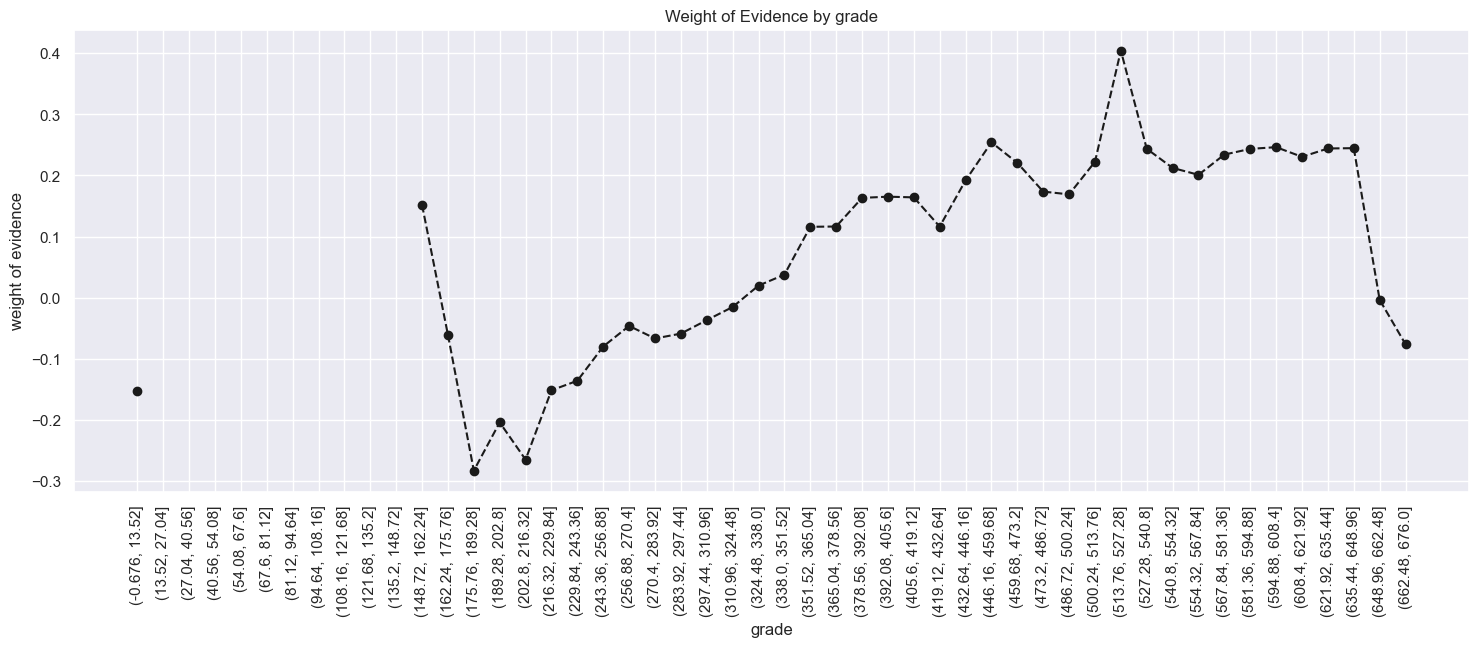

In [140]:
#plot the woe_plot
plot_by_woe(df_temp,90)

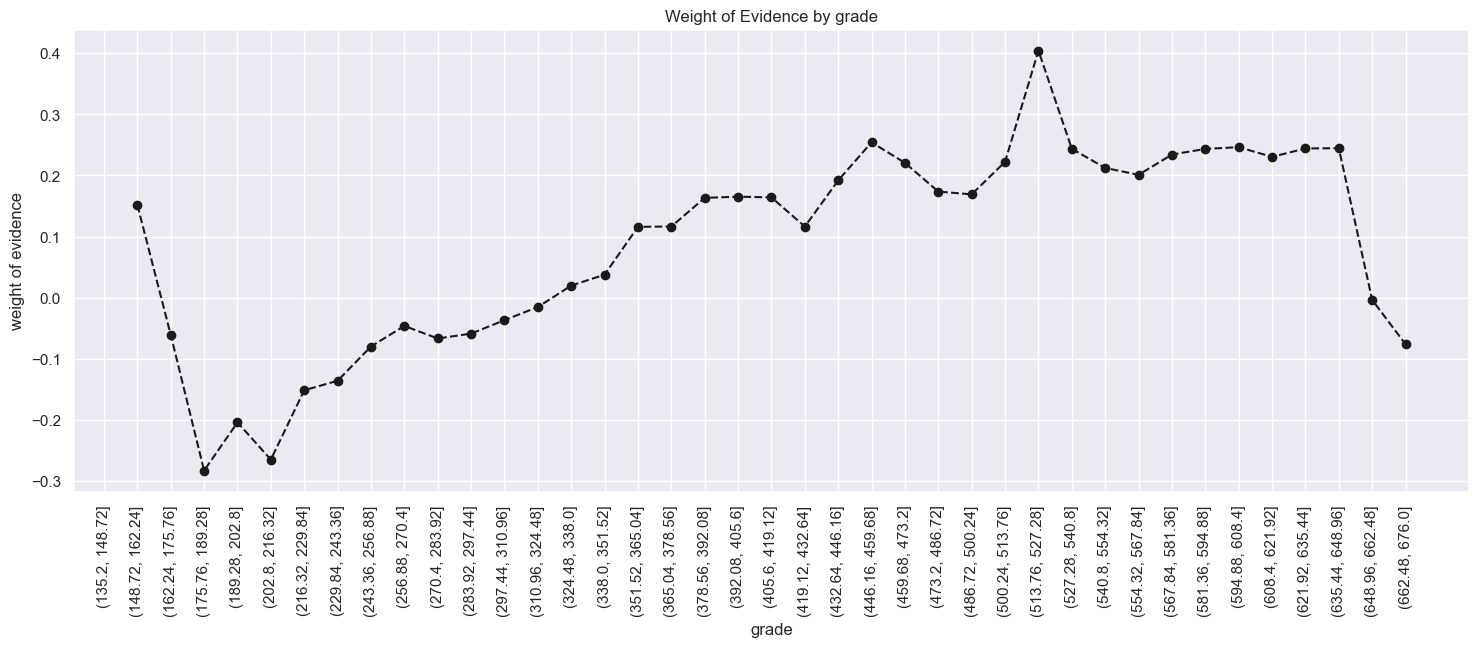

In [141]:
#plot for df_temp.iloc[3:,:],90
plot_by_woe(df_temp.iloc[3:,:],90)

In [142]:
###Convert it into binary encoded format by putting 1 and 0 inplace for WoE values that are close to each other

df_inputs_prepr['mths_since_earliest_cr_line:<140']=np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(140)),1,0)
df_inputs_prepr['mths_since_earliest_cr_line:140-239']=np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(140,240)),1,0)
df_inputs_prepr['mths_since_earliest_cr_line:240-339']=np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(240,340)),1,0)
df_inputs_prepr['mths_since_earliest_cr_line:340-439']=np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(340,440)),1,0)
df_inputs_prepr['mths_since_earliest_cr_line:440-539']=np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(440,540)),1,0)
df_inputs_prepr['mths_since_earliest_cr_line:540-600']=np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(540,601)),1,0)
df_inputs_prepr['mths_since_earliest_cr_line:>600']=np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(601,int(df_inputs_prepr['mths_since_earliest_cr_line'].max()))),1,0)

In [143]:
df_inputs_test['mths_since_earliest_cr_line:<140']=np.where(df_inputs_test['mths_since_earliest_cr_line'].isin(range(140)),1,0)
df_inputs_test['mths_since_earliest_cr_line:140-239']=np.where(df_inputs_test['mths_since_earliest_cr_line'].isin(range(140,240)),1,0)
df_inputs_test['mths_since_earliest_cr_line:240-339']=np.where(df_inputs_test['mths_since_earliest_cr_line'].isin(range(240,340)),1,0)
df_inputs_test['mths_since_earliest_cr_line:340-439']=np.where(df_inputs_test['mths_since_earliest_cr_line'].isin(range(340,440)),1,0)
df_inputs_test['mths_since_earliest_cr_line:440-539']=np.where(df_inputs_test['mths_since_earliest_cr_line'].isin(range(440,540)),1,0)
df_inputs_test['mths_since_earliest_cr_line:540-600']=np.where(df_inputs_test['mths_since_earliest_cr_line'].isin(range(540,601)),1,0)
df_inputs_test['mths_since_earliest_cr_line:>600']=np.where(df_inputs_test['mths_since_earliest_cr_line'].isin(range(601,int(df_inputs_test['mths_since_earliest_cr_line'].max()))),1,0)

In [144]:
#check the 'installment' unique values
df_inputs_prepr['installment'].unique()

array([762.08, 343.39, 648.56, ..., 718.44, 735.11, 464.48])

In [145]:
#apply the cut function and woe_continuos function on 'installment'
df_inputs_prepr['installment_factor']=pd.cut(df_inputs_prepr['installment'],50)
df_inputs_test['installment_factor']=pd.cut(df_inputs_test['installment'],50)
df_temp=woe_continuous(df_inputs_prepr,'installment_factor',df_targets_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(14.276, 43.556]",1812,0.906181,0.004858,1642.0,170.0,0.004942,0.004169,0.170127,NaN,NaN,0.013497
1,"(43.556, 71.443]",4841,0.897542,0.012978,4345.0,496.0,0.013078,0.012163,0.072460,0.008639,0.097667,0.013497
2,"(71.443, 99.329]",6824,0.893025,0.018294,6094.0,730.0,0.018342,0.017902,0.024270,0.004517,0.048190,0.013497
3,"(99.329, 127.216]",9138,0.890348,0.024497,8136.0,1002.0,0.024488,0.024572,-0.003444,0.002677,0.027715,0.013497
4,"(127.216, 155.102]",10040,0.896514,0.026915,9001.0,1039.0,0.027091,0.025479,0.061332,0.006166,0.064776,0.013497
5,"(155.102, 182.988]",16816,0.894208,0.045080,15037.0,1779.0,0.045258,0.043626,0.036717,0.002306,0.024615,0.013497
6,"(182.988, 210.875]",17216,0.904798,0.046152,15577.0,1639.0,0.046883,0.040193,0.153964,0.010590,0.117247,0.013497
7,"(210.875, 238.761]",15090,0.900398,0.040453,13587.0,1503.0,0.040894,0.036858,0.103905,0.004400,0.050059,0.013497
8,"(238.761, 266.648]",18842,0.901391,0.050511,16984.0,1858.0,0.051118,0.045564,0.115026,0.000993,0.011121,0.013497
9,"(266.648, 294.534]",20100,0.891095,0.053883,17911.0,2189.0,0.053908,0.053681,0.004225,0.010296,0.110801,0.013497


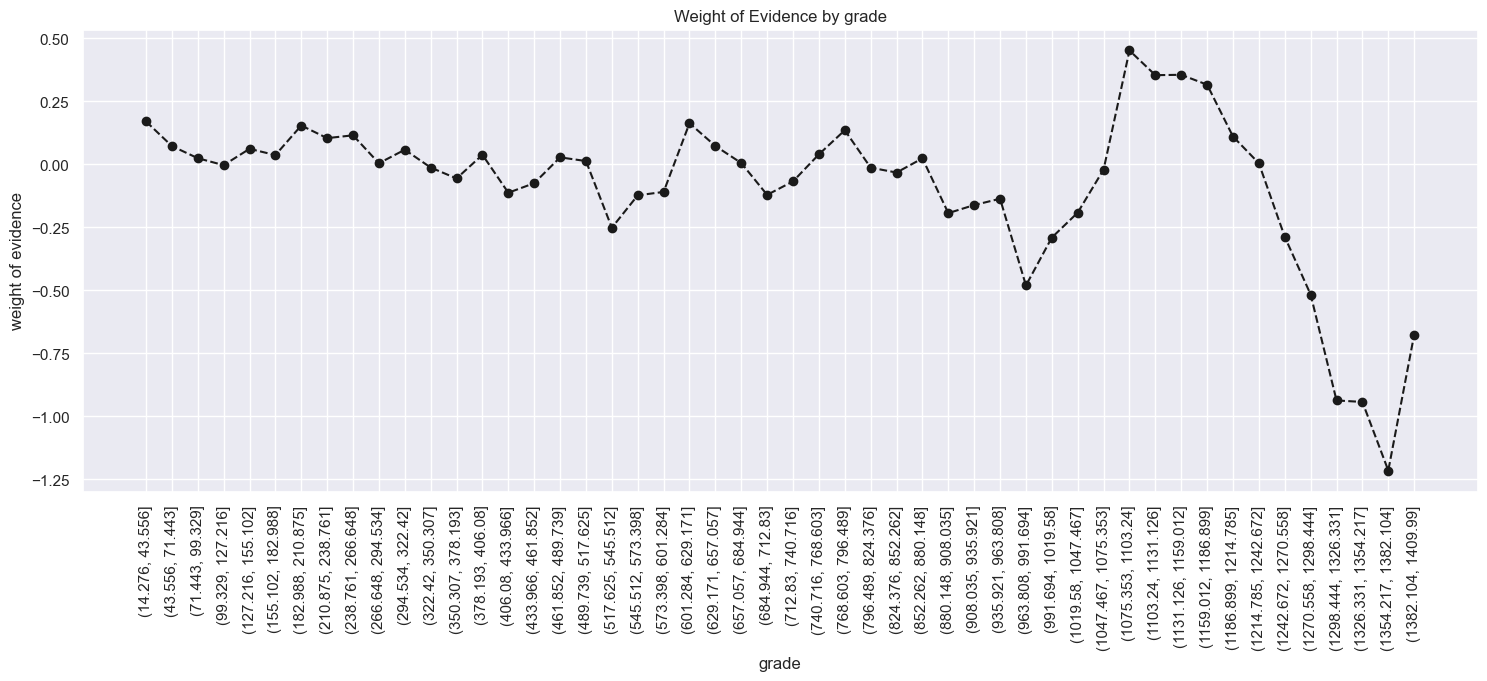

In [146]:
#plot the woe_plot
plot_by_woe(df_temp,90)

In [147]:
#check the 'delinq_2yrs' column
df_inputs_prepr['delinq_2yrs'].unique()
df_inputs_prepr['delinq_2yrs'].astype(float)
df_inputs_test['delinq_2yrs'].astype(float)

362514    0.0
288564    1.0
213591    0.0
263083    0.0
165001    0.0
         ... 
115       0.0
296284    0.0
61777     0.0
91763     0.0
167512    0.0
Name: delinq_2yrs, Length: 93257, dtype: float64

In [148]:
#apply the woe_continuous function
df_temp=woe_continuous(df_inputs_prepr,'delinq_2yrs',df_targets_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,306393,0.890500,0.821367,272843.0,33550.0,0.821198,0.822748,-0.001885,NaN,NaN,inf
1,1.0,44927,0.893249,0.120439,40131.0,4796.0,0.120786,0.117612,0.026622,0.002749,0.028507,inf
2,2.0,13118,0.889007,0.035166,11662.0,1456.0,0.035100,0.035706,-0.017102,0.004242,0.043724,inf
3,3.0,4550,0.883297,0.012197,4019.0,531.0,0.012096,0.013022,-0.073719,0.005711,0.056616,inf
4,4.0,1868,0.898822,0.005008,1679.0,189.0,0.005053,0.004635,0.086462,0.015526,0.160180,inf
5,5.0,966,0.881988,0.002590,852.0,114.0,0.002564,0.002796,-0.086357,0.016835,0.172819,inf
6,6.0,501,0.902196,0.001343,452.0,49.0,0.001360,0.001202,0.124117,0.020208,0.210474,inf
7,7.0,279,0.860215,0.000748,240.0,39.0,0.000722,0.000956,-0.280668,0.041981,0.404785,inf
8,8.0,148,0.905405,0.000397,134.0,14.0,0.000403,0.000343,0.161037,0.045190,0.441705,inf
9,9.0,89,0.887640,0.000239,79.0,10.0,0.000238,0.000245,-0.030882,0.017765,0.191920,inf


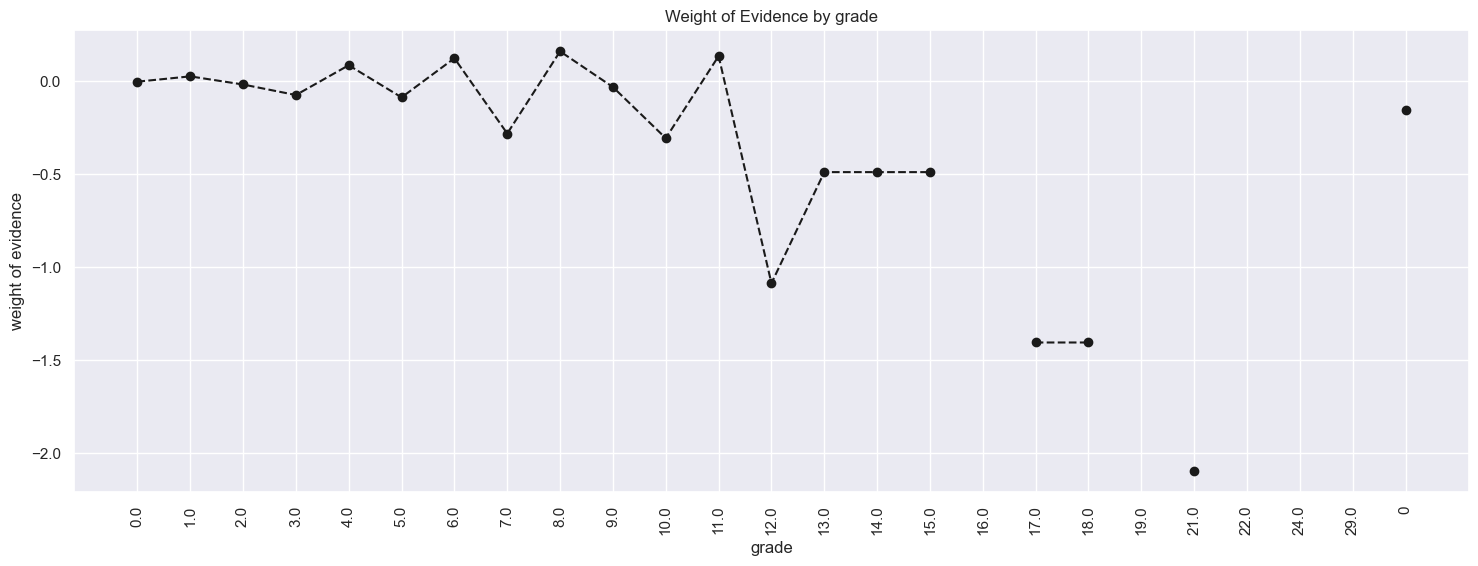

In [149]:
#plot the woe_plot
plot_by_woe(df_temp,90)

In [150]:
###Convert it into binary encoded format by putting 1 and 0 inplace for WoE values that are close to each other

df_inputs_prepr['delinq_2yrs:0']=np.where(df_inputs_prepr['delinq_2yrs'].isin(range(0)),1,0)
df_inputs_prepr['delinq_2yrs:0-3']=np.where(df_inputs_prepr['delinq_2yrs'].isin(range(0,4)),1,0)
df_inputs_prepr['delinq_2yrs:3-7']=np.where(df_inputs_prepr['delinq_2yrs'].isin(range(4,8)),1,0)
df_inputs_prepr['delinq_2yrs:7-9']=np.where(df_inputs_prepr['delinq_2yrs'].isin(range(8,10)),1,0)
df_inputs_prepr['delinq_2yrs:9-11']=np.where(df_inputs_prepr['delinq_2yrs'].isin(range(10,12)),1,0)
df_inputs_prepr['delinq_2yrs:11-12']=np.where(df_inputs_prepr['delinq_2yrs'].isin(range(12,13)),1,0)
df_inputs_prepr['delinq_2yrs:12-18']=np.where(df_inputs_prepr['delinq_2yrs'].isin(range(13,19)),1,0)
df_inputs_prepr['delinq_2yrs:>18']=np.where(df_inputs_prepr['delinq_2yrs'].isin(range(19,31)),1,0)

In [151]:
df_inputs_test['delinq_2yrs:0']=np.where(df_inputs_test['delinq_2yrs'].isin(range(0)),1,0)
df_inputs_test['delinq_2yrs:0-3']=np.where(df_inputs_test['delinq_2yrs'].isin(range(0,4)),1,0)
df_inputs_test['delinq_2yrs:3-7']=np.where(df_inputs_test['delinq_2yrs'].isin(range(4,8)),1,0)
df_inputs_test['delinq_2yrs:7-9']=np.where(df_inputs_test['delinq_2yrs'].isin(range(8,10)),1,0)
df_inputs_test['delinq_2yrs:9-11']=np.where(df_inputs_test['delinq_2yrs'].isin(range(10,12)),1,0)
df_inputs_test['delinq_2yrs:11-12']=np.where(df_inputs_test['delinq_2yrs'].isin(range(12,13)),1,0)
df_inputs_test['delinq_2yrs:12-18']=np.where(df_inputs_test['delinq_2yrs'].isin(range(13,19)),1,0)
df_inputs_test['delinq_2yrs:>18']=np.where(df_inputs_test['delinq_2yrs'].isin(range(19,31)),1,0)

In [152]:
#check the 'inq_last_6mths' column
df_inputs_prepr['inq_last_6mths'].unique()
df_inputs_prepr['inq_last_6mths']=pd.to_numeric(df_inputs_prepr['inq_last_6mths'])
df_inputs_test['inq_last_6mths']=pd.to_numeric(df_inputs_test['inq_last_6mths'])

In [153]:
#apply the woe_continuous function
df_temp=woe_continuous(df_inputs_prepr,'inq_last_6mths',df_targets_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,193232,0.908395,0.518009,175531.0,17701.0,0.528310,0.434082,0.196450,NaN,NaN,inf
1,1.0,104163,0.884950,0.279236,92179.0,11984.0,0.277439,0.293884,-0.057585,0.023446,0.254035,inf
2,2.0,46214,0.864197,0.123889,39938.0,6276.0,0.120205,0.153907,-0.247150,0.020753,0.189564,inf
3,3.0,20040,0.839671,0.053723,16827.0,3213.0,0.050646,0.078792,-0.441965,0.024526,0.194816,inf
4,4.0,5810,0.848365,0.015575,4929.0,881.0,0.014835,0.021605,-0.375911,0.008694,0.066054,inf
5,5.0,2217,0.824989,0.005943,1829.0,388.0,0.005505,0.009515,-0.547226,0.023376,0.171314,inf
6,6.0,977,0.788127,0.002619,770.0,207.0,0.002318,0.005076,-0.784073,0.036862,0.236848,inf
7,7.0,159,0.679245,0.000426,108.0,51.0,0.000325,0.001251,-1.347439,0.108882,0.563366,inf
8,8.0,101,0.643564,0.000271,65.0,36.0,0.000196,0.000883,-1.506877,0.035681,0.159437,inf
9,9.0,43,0.674419,0.000115,29.0,14.0,0.000087,0.000343,-1.369506,0.030854,0.137370,inf


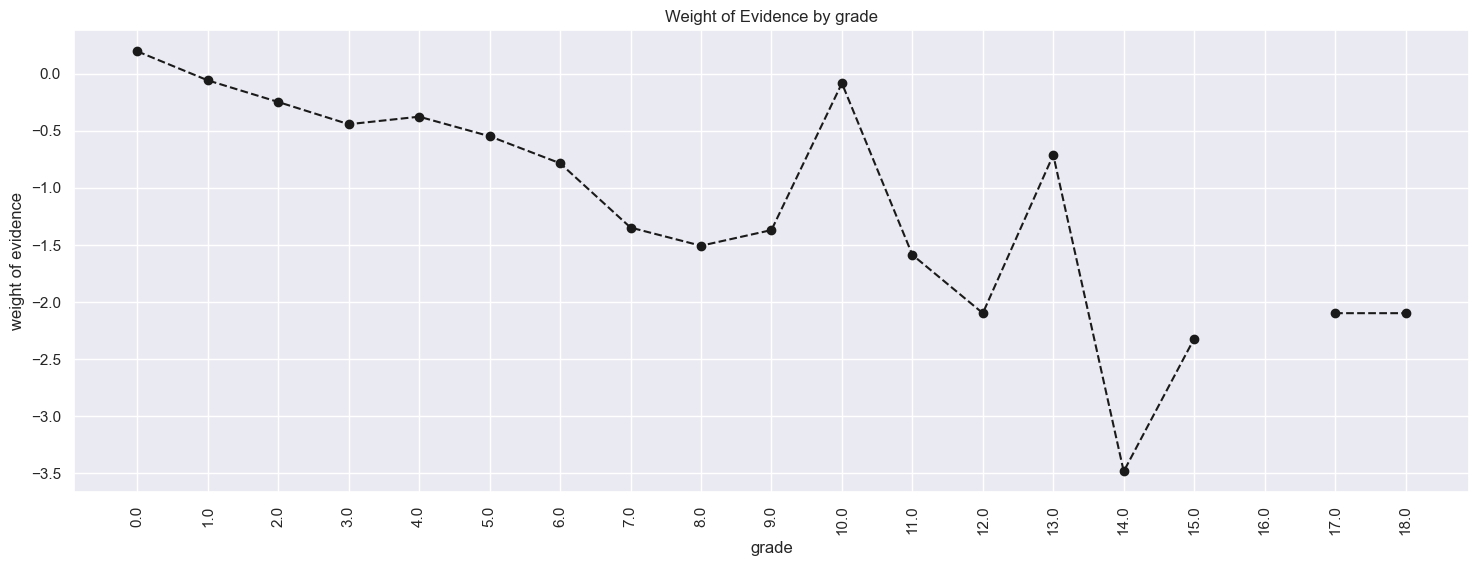

In [154]:
#plot the woe_plot
plot_by_woe(df_temp,90)

In [155]:
###Convert it into binary encoded format by putting 1 and 0 inplace for WoE values that are close to each other

df_inputs_prepr['inq_last_6mths:0']=np.where(df_inputs_prepr['inq_last_6mths']==0,1,0)
df_inputs_prepr['inq_last_6mths:1-2']=np.where((df_inputs_prepr['inq_last_6mths']>=1)&(df_inputs_prepr['inq_last_6mths']<=2),1,0)
df_inputs_prepr['inq_last_6mths:4-6']=np.where((df_inputs_prepr['inq_last_6mths']>=4)&(df_inputs_prepr['inq_last_6mths']<=6),1,0)
df_inputs_prepr['inq_last_6mths:7-9']=np.where((df_inputs_prepr['inq_last_6mths']>=7)&(df_inputs_prepr['inq_last_6mths']<=9),1,0)
df_inputs_prepr['inq_last_6mths:10-11']=np.where((df_inputs_prepr['inq_last_6mths']>=10)&(df_inputs_prepr['inq_last_6mths']<=11),1,0)
df_inputs_prepr['inq_last_6mths:12-13']=np.where((df_inputs_prepr['inq_last_6mths']>=12)&(df_inputs_prepr['inq_last_6mths']<=13),1,0)
df_inputs_prepr['inq_last_6mths:14-17']=np.where((df_inputs_prepr['inq_last_6mths']>=14)&(df_inputs_prepr['inq_last_6mths']<=17),1,0)
df_inputs_prepr['inq_last_6mths:18']=np.where((df_inputs_prepr['inq_last_6mths']>=18),1,0)

In [156]:
df_inputs_test['inq_last_6mths:0']=np.where(df_inputs_test['inq_last_6mths']==0,1,0)
df_inputs_test['inq_last_6mths:1-2']=np.where((df_inputs_test['inq_last_6mths']>=1)&(df_inputs_test['inq_last_6mths']<=2),1,0)
df_inputs_test['inq_last_6mths:4-6']=np.where((df_inputs_test['inq_last_6mths']>=4)&(df_inputs_test['inq_last_6mths']<=6),1,0)
df_inputs_test['inq_last_6mths:7-9']=np.where((df_inputs_test['inq_last_6mths']>=7)&(df_inputs_test['inq_last_6mths']<=9),1,0)
df_inputs_test['inq_last_6mths:10-11']=np.where((df_inputs_test['inq_last_6mths']>=10)&(df_inputs_test['inq_last_6mths']<=11),1,0)
df_inputs_test['inq_last_6mths:12-13']=np.where((df_inputs_test['inq_last_6mths']>=12)&(df_inputs_test['inq_last_6mths']<=13),1,0)
df_inputs_test['inq_last_6mths:14-17']=np.where((df_inputs_test['inq_last_6mths']>=14)&(df_inputs_test['inq_last_6mths']<=17),1,0)
df_inputs_test['inq_last_6mths:18']=np.where((df_inputs_test['inq_last_6mths']>=18),1,0)

In [157]:
#convert the 'open_acc' into float and then apply the woe_continuos function

df_inputs_prepr['open_acc']=pd.to_numeric(df_inputs_prepr['open_acc'])
df_inputs_test['open_acc']=pd.to_numeric(df_inputs_test['open_acc'])
df_temp=woe_continuous(df_inputs_prepr,'open_acc',df_targets_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,29,0.758621,0.000078,22.0,7.0,0.000066,0.000172,-0.952613,NaN,NaN,inf
1,1.0,110,0.872727,0.000295,96.0,14.0,0.000289,0.000343,-0.172454,0.114107,0.780159,inf
2,2.0,1456,0.845467,0.003903,1231.0,225.0,0.003705,0.005518,-0.398263,0.027260,0.225809,inf
3,3.0,4378,0.873687,0.011736,3825.0,553.0,0.011512,0.013561,-0.163789,0.028220,0.234474,inf
4,4.0,10028,0.891504,0.026883,8940.0,1088.0,0.026907,0.026681,0.008449,0.017817,0.172239,inf
5,5.0,17141,0.891255,0.045951,15277.0,1864.0,0.045980,0.045711,0.005879,0.000249,0.002571,inf
6,6.0,24621,0.892368,0.066003,21971.0,2650.0,0.066128,0.064986,0.017419,0.001113,0.011540,inf
7,7.0,30169,0.891544,0.080876,26897.0,3272.0,0.080954,0.080239,0.008868,0.000824,0.008550,inf
8,8.0,33579,0.891033,0.090017,29920.0,3659.0,0.090053,0.089730,0.003592,0.000511,0.005276,inf
9,9.0,35251,0.889195,0.094500,31345.0,3906.0,0.094342,0.095787,-0.015204,0.001838,0.018796,inf


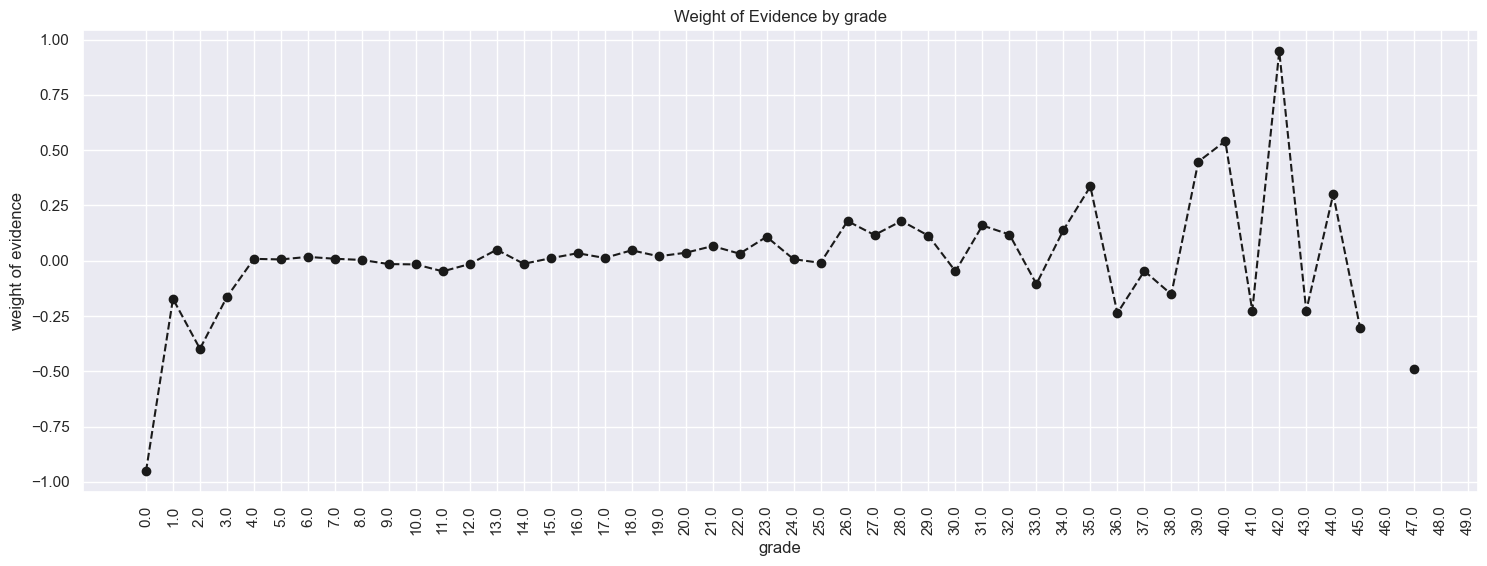

In [158]:
#plot the woe_plot
plot_by_woe(df_temp,90)

In [159]:
###Convert it into binary encoded format by putting 1 and 0 inplace for WoE values that are close to each other
df_inputs_prepr['open_acc:=0']=np.where((df_inputs_prepr['open_acc']==0),1,0)
df_inputs_prepr['open_acc:1-3']=np.where((df_inputs_prepr['open_acc']>=1)&(df_inputs_prepr['open_acc']<=3),1,0)
df_inputs_prepr['open_acc:4-12']=np.where((df_inputs_prepr['open_acc']>=4)&(df_inputs_prepr['open_acc']<=12),1,0)
df_inputs_prepr['open_acc:13-17']=np.where((df_inputs_prepr['open_acc']>=13)&(df_inputs_prepr['open_acc']<=17),1,0)
df_inputs_prepr['open_acc:18-22']=np.where((df_inputs_prepr['open_acc']>=18)&(df_inputs_prepr['open_acc']<=22),1,0)
df_inputs_prepr['open_acc:23-25']=np.where((df_inputs_prepr['open_acc']>=23)&(df_inputs_prepr['open_acc']<=25),1,0)
df_inputs_prepr['open_acc:26-30']=np.where((df_inputs_prepr['open_acc']>=26)&(df_inputs_prepr['open_acc']<=30),1,0)
df_inputs_prepr['open_acc:>31']=np.where((df_inputs_prepr['open_acc']>=31),1,0)

In [160]:
df_inputs_test['open_acc:=0']=np.where((df_inputs_test['open_acc']==0),1,0)
df_inputs_test['open_acc:1-3']=np.where((df_inputs_test['open_acc']>=1)&(df_inputs_test['open_acc']<=3),1,0)
df_inputs_test['open_acc:4-12']=np.where((df_inputs_test['open_acc']>=4)&(df_inputs_test['open_acc']<=12),1,0)
df_inputs_test['open_acc:13-17']=np.where((df_inputs_test['open_acc']>=13)&(df_inputs_test['open_acc']<=17),1,0)
df_inputs_test['open_acc:18-22']=np.where((df_inputs_test['open_acc']>=18)&(df_inputs_test['open_acc']<=22),1,0)
df_inputs_test['open_acc:23-25']=np.where((df_inputs_test['open_acc']>=23)&(df_inputs_test['open_acc']<=25),1,0)
df_inputs_test['open_acc:26-30']=np.where((df_inputs_test['open_acc']>=26)&(df_inputs_test['open_acc']<=30),1,0)
df_inputs_test['open_acc:>31']=np.where((df_inputs_test['open_acc']>=31),1,0)

In [161]:
#convert the 'pub_rec' into float
df_inputs_prepr['pub_rec']=df_inputs_prepr['pub_rec'].astype(float)
df_inputs_test['pub_rec']=df_inputs_test['pub_rec'].astype(float)

In [162]:
#apply the woe_continuous function
df_temp=woe_continuous(df_inputs_prepr,'pub_rec',df_targets_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,323999,0.889941,0.868565,288340.0,35659.0,0.867840,0.874467,-0.007606,NaN,NaN,inf
1,1.0,42381,0.893419,0.113613,37864.0,4517.0,0.113962,0.110771,0.028408,0.003478,0.036014,inf
2,2.0,4527,0.903247,0.012136,4089.0,438.0,0.012307,0.010741,0.136092,0.009828,0.107684,inf
3,3.0,1280,0.920312,0.003431,1178.0,102.0,0.003546,0.002501,0.348856,0.017065,0.212764,inf
4,4.0,408,0.924020,0.001094,377.0,31.0,0.001135,0.000760,0.400513,0.003707,0.051657,inf
5,5.0,203,0.911330,0.000544,185.0,18.0,0.000557,0.000441,0.232239,0.012690,0.168274,inf
6,6.0,117,0.931624,0.000314,109.0,8.0,0.000328,0.000196,0.514161,0.020294,0.281922,inf
7,7.0,48,0.958333,0.000129,46.0,2.0,0.000138,0.000049,1.037749,0.026709,0.523588,inf
8,8.0,24,1.000000,0.000064,24.0,0.0,0.000072,0.000000,inf,0.041667,inf,inf
9,9.0,14,0.785714,0.000038,11.0,3.0,0.000033,0.000074,-0.798462,0.214286,inf,inf


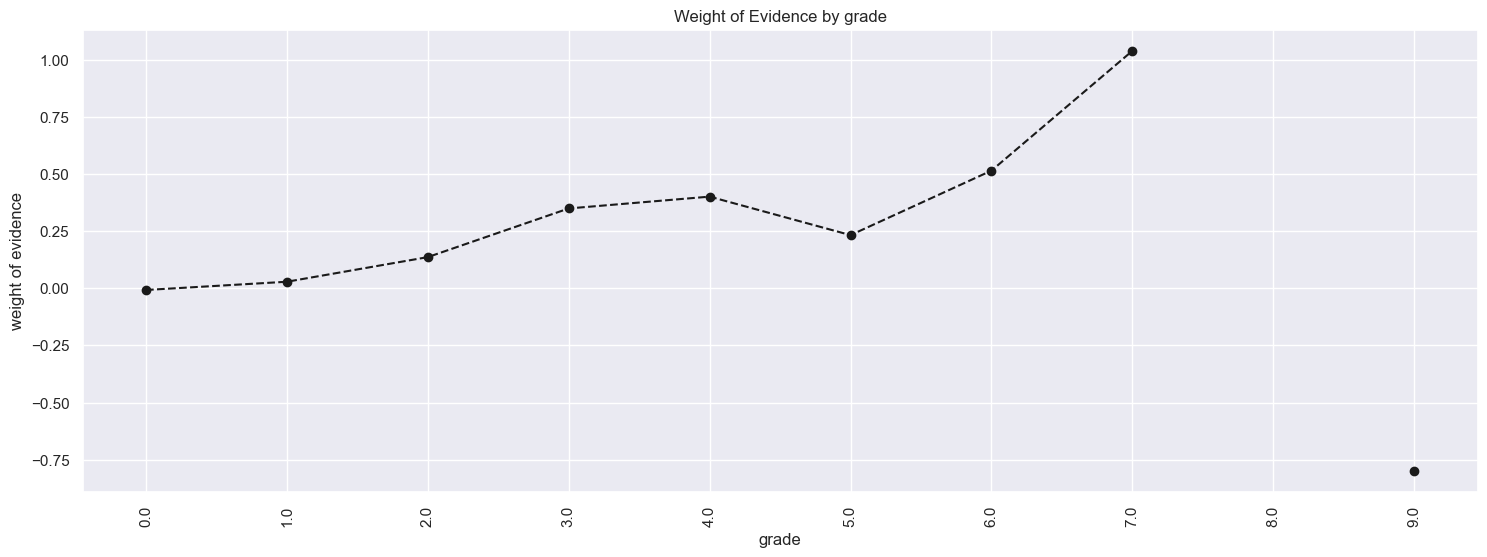

In [163]:
#plot the woe_plot
plot_by_woe(df_temp,90)

In [164]:
###Convert it into binary encoded format by putting 1 and 0 inplace for WoE values that are close to each other
df_inputs_prepr['pub_rec:0-2']=np.where(df_inputs_prepr['pub_rec'].isin(range(0,3)),1,0)
df_inputs_prepr['pub_rec:3-4']=np.where(df_inputs_prepr['pub_rec'].isin(range(3,5)),1,0)
df_inputs_prepr['pub_rec:>5']=np.where(df_inputs_prepr['pub_rec'].isin(range(5,10)),1,0)

In [165]:
df_inputs_test['pub_rec:0-2']=np.where(df_inputs_test['pub_rec'].isin(range(0,3)),1,0)
df_inputs_test['pub_rec:3-4']=np.where(df_inputs_test['pub_rec'].isin(range(3,5)),1,0)
df_inputs_test['pub_rec:>5']=np.where(df_inputs_test['pub_rec'].isin(range(5,10)),1,0)

In [166]:
#convert the 'total_acc' into float
df_inputs_prepr['total_acc']=df_inputs_prepr['total_acc'].astype(float)
df_inputs_test['total_acc']=df_inputs_test['total_acc'].astype(float)

In [167]:
#apply the cut function to create buckets of continuos variables
df_inputs_prepr['total_acc_fac']=pd.cut(df_inputs_prepr['total_acc'],50)
df_inputs_test['total_acc_fac']=pd.cut(df_inputs_test['total_acc'],50)

In [168]:
#apply the woe_continuos function
df_temp=woe_continuous(df_inputs_prepr,'total_acc_fac',df_targets_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.15, 3.0]",459,0.810458,0.001230,372.0,87.0,0.001120,0.002134,-0.644759,NaN,NaN,inf
1,"(3.0, 6.0]",6004,0.864757,0.016095,5192.0,812.0,0.015627,0.019913,-0.242371,0.054299,0.402388,inf
2,"(6.0, 9.0]",15047,0.873131,0.040337,13138.0,1909.0,0.039543,0.046814,-0.168816,0.008374,0.073555,inf
3,"(9.0, 12.0]",25169,0.881283,0.067472,22181.0,2988.0,0.066760,0.073275,-0.093113,0.008152,0.075703,inf
4,"(12.0, 15.0]",33651,0.881281,0.090210,29656.0,3995.0,0.089258,0.097969,-0.093124,0.000001,0.000011,inf
5,"(15.0, 18.0]",38711,0.887267,0.103775,34347.0,4364.0,0.103377,0.107018,-0.034619,0.005986,0.058505,inf
6,"(18.0, 21.0]",40599,0.886155,0.108836,35977.0,4622.0,0.108283,0.113345,-0.045693,0.001112,0.011073,inf
7,"(21.0, 24.0]",40163,0.891492,0.107668,35805.0,4358.0,0.107765,0.106871,0.008329,0.005337,0.054022,inf
8,"(24.0, 27.0]",36286,0.895442,0.097274,32492.0,3794.0,0.097794,0.093040,0.049828,0.003950,0.041499,inf
9,"(27.0, 30.0]",31775,0.899103,0.085181,28569.0,3206.0,0.085986,0.078621,0.089553,0.003661,0.039725,inf


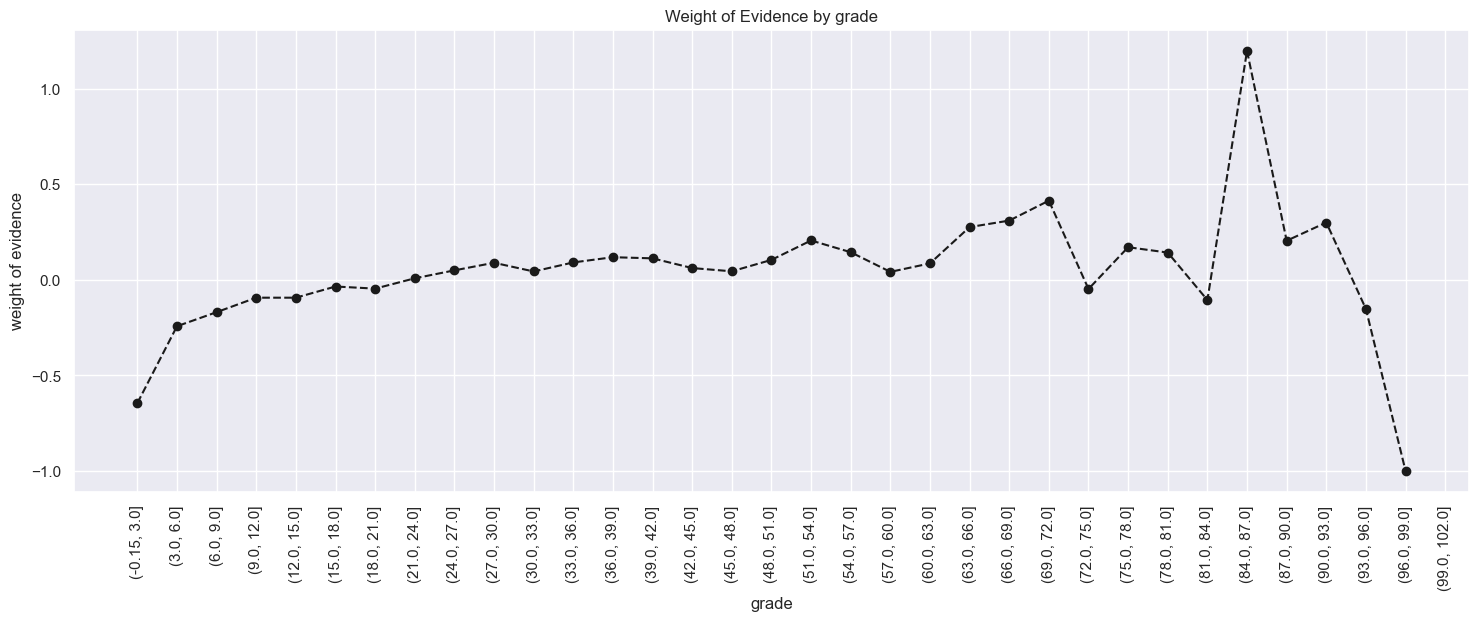

In [169]:
#plot the woe_plot
plot_by_woe(df_temp,90)

In [170]:
###Convert it into binary encoded format by putting 1 and 0 inplace for WoE values that are close to each other

df_inputs_prepr['total_acc:<0']=np.where((df_inputs_prepr['total_acc']<0),1,0)
df_inputs_prepr['total_acc:0-4']=np.where((df_inputs_prepr['total_acc']>=0)&(df_inputs_prepr['total_acc']<4),1,0)
df_inputs_prepr['total_acc:4-62']=np.where((df_inputs_prepr['total_acc']>=4)&(df_inputs_prepr['total_acc']<62),1,0)
df_inputs_prepr['total_acc:62-72']=np.where((df_inputs_prepr['total_acc']>=62)&(df_inputs_prepr['total_acc']<72),1,0)
df_inputs_prepr['total_acc:72-85']=np.where((df_inputs_prepr['total_acc']>=72)&(df_inputs_prepr['total_acc']<85),1,0)
df_inputs_prepr['total_acc:>85']=np.where((df_inputs_prepr['total_acc']>=85),1,0)

df_inputs_test['total_acc:<0']=np.where((df_inputs_test['total_acc']<0),1,0)
df_inputs_test['total_acc:0-4']=np.where((df_inputs_test['total_acc']>=0)&(df_inputs_test['total_acc']<4),1,0)
df_inputs_test['total_acc:4-62']=np.where((df_inputs_test['total_acc']>=4)&(df_inputs_test['total_acc']<62),1,0)
df_inputs_test['total_acc:62-72']=np.where((df_inputs_test['total_acc']>=62)&(df_inputs_test['total_acc']<72),1,0)
df_inputs_test['total_acc:72-85']=np.where((df_inputs_test['total_acc']>=72)&(df_inputs_test['total_acc']<85),1,0)
df_inputs_test['total_acc:>85']=np.where((df_inputs_test['total_acc']>=85),1,0)

In [171]:
#convert the 'acc_now_delinq' into float type
df_inputs_prepr['acc_now_delinq']=df_inputs_prepr['acc_now_delinq'].astype(float)
df_inputs_test['acc_now_delinq']=df_inputs_test['acc_now_delinq'].astype(float)

In [172]:
#apply the woe_continuos function
df_temp=woe_continuous(df_inputs_prepr,'acc_now_delinq',df_targets_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,371682,0.890648,0.996392,331038.0,40644.0,0.996352,0.996714,-0.000363,NaN,NaN,inf
1,1.0,1263,0.899446,0.003386,1136.0,127.0,0.003419,0.003114,0.093337,0.008797,0.093700,inf
2,2.0,70,0.928571,0.000188,65.0,5.0,0.000196,0.000123,0.467204,0.029126,0.373868,inf
3,3.0,7,0.857143,0.000019,6.0,1.0,0.000018,0.000025,-0.305986,0.071429,0.773190,inf
4,4.0,4,1.000000,0.000011,4.0,0.0,0.000012,0.000000,inf,0.142857,inf,inf
5,5.0,2,0.500000,0.000005,1.0,1.0,0.000003,0.000025,-2.097745,0.500000,inf,inf


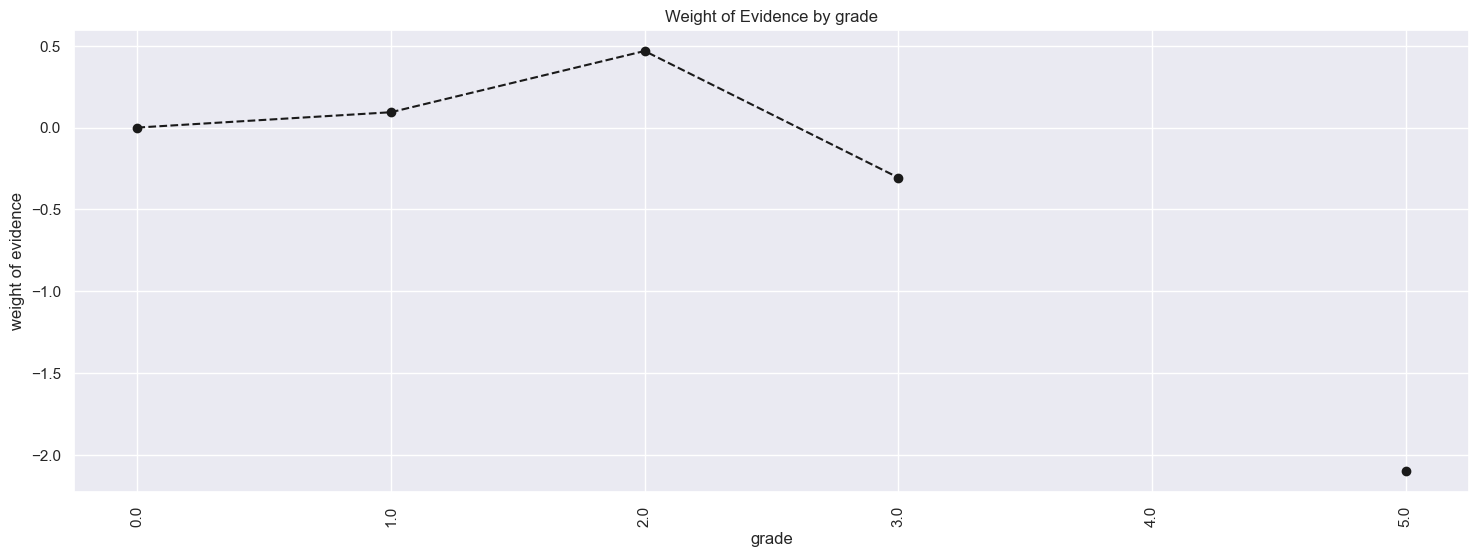

In [173]:
#plot the woe_plot
plot_by_woe(df_temp,90)

In [174]:
###Convert it into binary encoded format by putting 1 and 0 inplace for WoE values that are close to each other

df_inputs_prepr['acc_now_delinq:=0']=np.where(df_inputs_prepr['acc_now_delinq'].isin(range(0)),1,0)
df_inputs_prepr['acc_now_delinq:>=1']=np.where(df_inputs_prepr['acc_now_delinq'].isin(range(0,7)),1,0)
df_inputs_test['acc_now_delinq:=0']=np.where(df_inputs_test['acc_now_delinq'].isin(range(0)),1,0)
df_inputs_test['acc_now_delinq:>=1']=np.where(df_inputs_test['acc_now_delinq'].isin(range(0,7)),1,0)

In [175]:
#For 'total_rev_hi_lim' column take only those values which are less than 80000

df_inputs_prepr_temp=df_inputs_prepr.loc[df_inputs_prepr['total_rev_hi_lim']<= 80000,:]
df_inputs_test_temp=df_inputs_test.loc[df_inputs_test['total_rev_hi_lim']<= 80000,:]

In [176]:
#apply the cut and woe_continuos function
df_inputs_prepr['total_rev_hi_lim_factor']=pd.cut(df_inputs_prepr_temp['total_rev_hi_lim'],50)
df_inputs_test['total_rev_hi_lim_factor']=pd.cut(df_inputs_test_temp['total_rev_hi_lim'],50)
df_temp=woe_continuous(df_inputs_prepr,'total_rev_hi_lim_factor',df_targets_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-80.0, 1600.0]",2111,0.852676,0.005885,1800.0,311.0,0.005647,0.007785,-0.321080,NaN,NaN,0.031724
1,"(1600.0, 3200.0]",6628,0.860742,0.018477,5705.0,923.0,0.017897,0.023104,-0.255360,0.008066,0.065720,0.031724
2,"(3200.0, 4800.0]",10146,0.872068,0.028284,8848.0,1298.0,0.027757,0.032491,-0.157462,0.011326,0.097898,0.031724
3,"(4800.0, 6400.0]",16177,0.870681,0.045097,14085.0,2092.0,0.044186,0.052365,-0.169839,0.001387,0.012377,0.031724
4,"(6400.0, 8000.0]",17741,0.877684,0.049457,15571.0,2170.0,0.048848,0.054318,-0.106146,0.007004,0.063693,0.031724
5,"(8000.0, 9600.0]",16342,0.879696,0.045557,14376.0,1966.0,0.045099,0.049212,-0.087269,0.002012,0.018876,0.031724
6,"(9600.0, 11200.0]",20261,0.876709,0.056482,17763.0,2498.0,0.055724,0.062528,-0.115201,0.002988,0.027932,0.031724
7,"(11200.0, 12800.0]",19579,0.881352,0.054581,17256.0,2323.0,0.054134,0.058148,-0.071528,0.004644,0.043673,0.031724
8,"(12800.0, 14400.0]",17424,0.882978,0.048573,15385.0,2039.0,0.048264,0.051039,-0.055895,0.001625,0.015633,0.031724
9,"(14400.0, 16000.0]",19636,0.872021,0.054740,17123.0,2513.0,0.053717,0.062904,-0.157883,0.010957,0.101988,0.031724


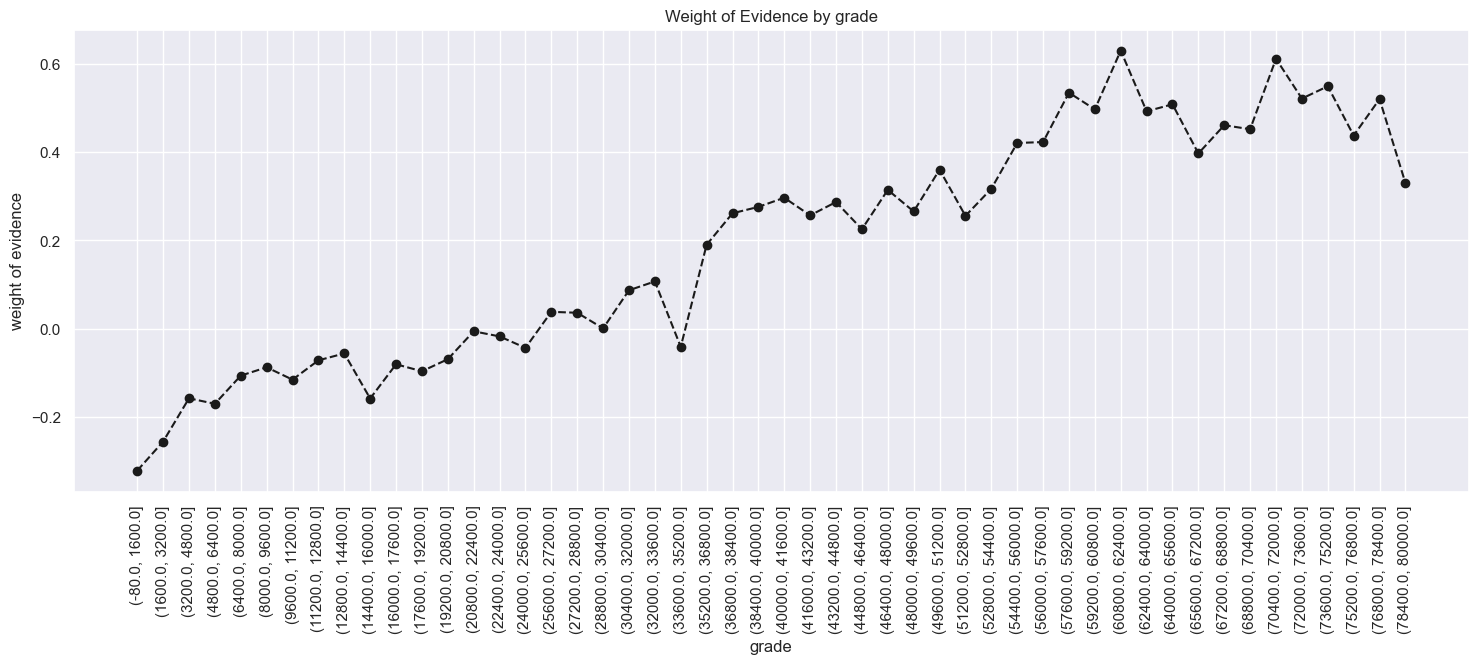

In [177]:
#plot the woe_plot
plot_by_woe(df_temp,90)

In [178]:
###Convert it into binary encoded format by putting 1 and 0 inplace for WoE values that are close to each other

df_inputs_prepr['total_rev_hi_lim:<=5k']=np.where(df_inputs_prepr['total_rev_hi_lim']<=5000,1,0)
df_inputs_prepr['total_rev_hi_lim:5k_10k']=np.where((df_inputs_prepr['total_rev_hi_lim']<10001)&(df_inputs_prepr['total_rev_hi_lim']>5000),1,0)
df_inputs_prepr['total_rev_hi_lim:10k_20k']=np.where((df_inputs_prepr['total_rev_hi_lim']<20001)&(df_inputs_prepr['total_rev_hi_lim']>10000),1,0)
df_inputs_prepr['total_rev_hi_lim:20k_30k']=np.where((df_inputs_prepr['total_rev_hi_lim']<30001)&(df_inputs_prepr['total_rev_hi_lim']>20000),1,0)
df_inputs_prepr['total_rev_hi_lim:30k_40k']=np.where((df_inputs_prepr['total_rev_hi_lim']<40001)&(df_inputs_prepr['total_rev_hi_lim']>30000),1,0)
df_inputs_prepr['total_rev_hi_lim:40k_50k']=np.where((df_inputs_prepr['total_rev_hi_lim']<50001)&(df_inputs_prepr['total_rev_hi_lim']>40000),1,0)
df_inputs_prepr['total_rev_hi_lim:50k_65k']=np.where((df_inputs_prepr['total_rev_hi_lim']<650001)&(df_inputs_prepr['total_rev_hi_lim']>50000),1,0)
df_inputs_prepr['total_rev_hi_lim:65k_80k']=np.where((df_inputs_prepr['total_rev_hi_lim']<80001)&(df_inputs_prepr['total_rev_hi_lim']>65000),1,0)
df_inputs_prepr['total_rev_hi_lim:>80k']=np.where(df_inputs_prepr['total_rev_hi_lim']>=80001,1,0)

In [179]:
df_inputs_test['total_rev_hi_lim:<=5k']=np.where(df_inputs_test['total_rev_hi_lim']<=5000,1,0)
df_inputs_test['total_rev_hi_lim:5k_10k']=np.where((df_inputs_test['total_rev_hi_lim']<10001)&(df_inputs_test['total_rev_hi_lim']>5000),1,0)
df_inputs_test['total_rev_hi_lim:10k_20k']=np.where((df_inputs_test['total_rev_hi_lim']<20001)&(df_inputs_test['total_rev_hi_lim']>10000),1,0)
df_inputs_test['total_rev_hi_lim:20k_30k']=np.where((df_inputs_test['total_rev_hi_lim']<30001)&(df_inputs_test['total_rev_hi_lim']>20000),1,0)
df_inputs_test['total_rev_hi_lim:30k_40k']=np.where((df_inputs_test['total_rev_hi_lim']<40001)&(df_inputs_test['total_rev_hi_lim']>30000),1,0)
df_inputs_test['total_rev_hi_lim:40k_50k']=np.where((df_inputs_test['total_rev_hi_lim']<50001)&(df_inputs_test['total_rev_hi_lim']>40000),1,0)
df_inputs_test['total_rev_hi_lim:50k_65k']=np.where((df_inputs_test['total_rev_hi_lim']<650001)&(df_inputs_test['total_rev_hi_lim']>50000),1,0)
df_inputs_test['total_rev_hi_lim:65k_80k']=np.where((df_inputs_test['total_rev_hi_lim']<80001)&(df_inputs_test['total_rev_hi_lim']>65000),1,0)
df_inputs_test['total_rev_hi_lim:>80k']=np.where(df_inputs_test['total_rev_hi_lim']>=80001,1,0)

In [180]:
#apply the cut and woe_continuous function on 'annual_inc'

df_inputs_prepr['annual_inc_factor']=pd.cut(df_inputs_prepr['annual_inc'],100)
df_inputs_test['annual_inc_factor']=pd.cut(df_inputs_test['annual_inc'],100)
df_temp=woe_continuous(df_inputs_prepr,'annual_inc_factor',df_targets_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-5243.882, 73294.82]",231445,0.875901,0.620449,202723.0,28722.0,0.610152,0.704350,-0.143568,NaN,NaN,inf
1,"(73294.82, 144693.64]",120459,0.912900,0.322922,109967.0,10492.0,0.330977,0.257296,0.251822,0.036998,0.395390,inf
2,"(144693.64, 216092.46]",15885,0.925087,0.042584,14695.0,1190.0,0.044229,0.029182,0.415809,0.012187,0.163987,inf
3,"(216092.46, 287491.28]",3119,0.927220,0.008361,2892.0,227.0,0.008704,0.005567,0.447009,0.002134,0.031200,inf
4,"(287491.28, 358890.1]",1117,0.929275,0.002994,1038.0,79.0,0.003124,0.001937,0.477858,0.002055,0.030850,inf
5,"(358890.1, 430288.92]",408,0.933824,0.001094,381.0,27.0,0.001147,0.000662,0.549218,0.004549,0.071359,inf
6,"(430288.92, 501687.74]",245,0.946939,0.000657,232.0,13.0,0.000698,0.000319,0.784043,0.013115,0.234826,inf
7,"(501687.74, 573086.56]",87,0.919540,0.000233,80.0,7.0,0.000241,0.000172,0.338372,0.027399,0.445672,inf
8,"(573086.56, 644485.38]",61,0.868852,0.000164,53.0,8.0,0.000160,0.000196,-0.206895,0.050688,0.545266,inf
9,"(644485.38, 715884.2]",51,0.901961,0.000137,46.0,5.0,0.000138,0.000123,0.121459,0.033108,0.328353,inf


As we can see higher values in annual_inc has very less observation so we will take only those annual income which are less than 140000

In [181]:
df_inputs_prepr_temp=df_inputs_prepr.loc[df_inputs_prepr['annual_inc']<=140000,:]
df_inputs_test_temp=df_inputs_test.loc[df_inputs_test['annual_inc']<=140000,:]

In [182]:
df_inputs_prepr['annual_inc_factor']=pd.cut(df_inputs_prepr_temp['annual_inc'],50)
df_inputs_test['annual_inc_factor']=pd.cut(df_inputs_test_temp['annual_inc'],50)
df_temp=woe_continuous(df_inputs_prepr,'annual_inc_factor',df_targets_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(1757.896, 4658.08]",15,0.800000,0.000043,12.0,3.0,0.000038,0.000077,-0.689458,NaN,NaN,0.049818
1,"(4658.08, 7420.16]",40,0.750000,0.000114,30.0,10.0,0.000096,0.000256,-0.977140,0.050000,0.287682,0.049818
2,"(7420.16, 10182.24]",287,0.874564,0.000818,251.0,36.0,0.000805,0.000920,-0.133818,0.124564,0.843322,0.049818
3,"(10182.24, 12944.32]",547,0.828154,0.001558,453.0,94.0,0.001452,0.002402,-0.503155,0.046411,0.369337,0.049818
4,"(12944.32, 15706.4]",1210,0.830579,0.003447,1005.0,205.0,0.003222,0.005238,-0.486019,0.002425,0.017135,0.049818
5,"(15706.4, 18468.48]",1522,0.847569,0.004335,1290.0,232.0,0.004136,0.005928,-0.360092,0.016990,0.125927,0.049818
6,"(18468.48, 21230.56]",2928,0.855533,0.008340,2505.0,423.0,0.008031,0.010809,-0.297080,0.007964,0.063012,0.049818
7,"(21230.56, 23992.64]",2495,0.844489,0.007107,2107.0,388.0,0.006755,0.009914,-0.383737,0.011044,0.086657,0.049818
8,"(23992.64, 26754.72]",7016,0.848632,0.019985,5954.0,1062.0,0.019088,0.027137,-0.351843,0.004143,0.031894,0.049818
9,"(26754.72, 29516.8]",5643,0.857345,0.016074,4838.0,805.0,0.015510,0.020570,-0.282338,0.008714,0.069505,0.049818


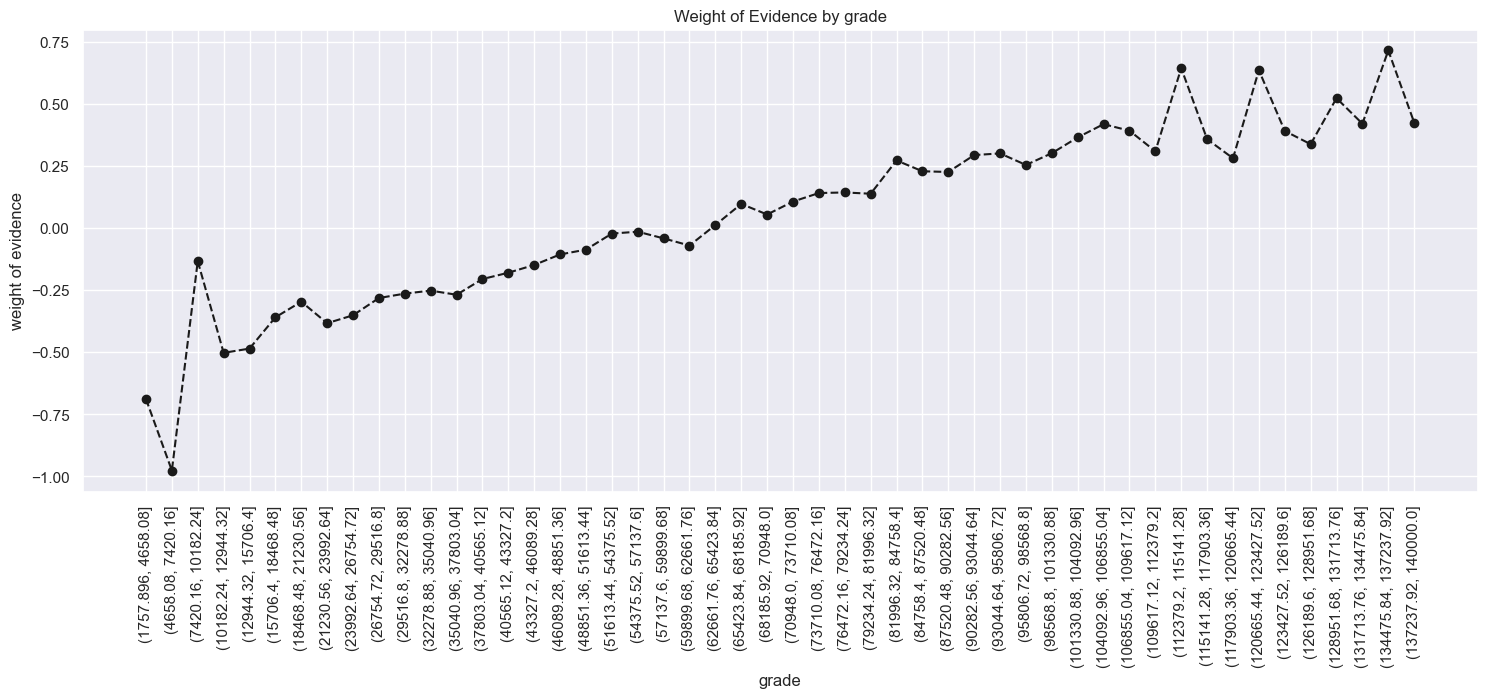

In [183]:
#plot the woe_plot
plot_by_woe(df_temp,90)

In [184]:
###Convert it into binary encoded format by putting 1 and 0 inplace for WoE values that are close to each other
#cut and labels
df_inputs_prepr['annual_inc:<20k']=np.where(df_inputs_prepr['annual_inc']<=20001,1,0)
df_inputs_prepr['annual_inc:20k-30k']=np.where((df_inputs_prepr['annual_inc']<=30001)&(df_inputs_prepr['annual_inc']>20001),1,0)
df_inputs_prepr['annual_inc:30k-40k']=np.where((df_inputs_prepr['annual_inc']<=40001)&(df_inputs_prepr['annual_inc']>30001),1,0)
df_inputs_prepr['annual_inc:40k-50k']=np.where((df_inputs_prepr['annual_inc']<=50001)&(df_inputs_prepr['annual_inc']>40001),1,0)
df_inputs_prepr['annual_inc:50k-60k']=np.where((df_inputs_prepr['annual_inc']<=60001)&(df_inputs_prepr['annual_inc']>50001),1,0)
df_inputs_prepr['annual_inc:60k-70k']=np.where((df_inputs_prepr['annual_inc']<=70001)&(df_inputs_prepr['annual_inc']>60001),1,0)
df_inputs_prepr['annual_inc:70k-80k']=np.where((df_inputs_prepr['annual_inc']<=80001)&(df_inputs_prepr['annual_inc']>70001),1,0)
df_inputs_prepr['annual_inc:80k-90k']=np.where((df_inputs_prepr['annual_inc']<=90001)&(df_inputs_prepr['annual_inc']>80001),1,0)
df_inputs_prepr['annual_inc:90k-100k']=np.where((df_inputs_prepr['annual_inc']<=100001)&(df_inputs_prepr['annual_inc']>90001),1,0)
df_inputs_prepr['annual_inc:100k-120k']=np.where((df_inputs_prepr['annual_inc']<=120001)&(df_inputs_prepr['annual_inc']>100001),1,0)
df_inputs_prepr['annual_inc:120k-140k']=np.where((df_inputs_prepr['annual_inc']<=140001)&(df_inputs_prepr['annual_inc']>120001),1,0)
df_inputs_prepr['annual_inc:>140k']=np.where(df_inputs_prepr['annual_inc']>140001,1,0)

In [185]:
df_inputs_test['annual_inc:<20k']=np.where(df_inputs_test['annual_inc']<=20001,1,0)
df_inputs_test['annual_inc:20k-30k']=np.where((df_inputs_test['annual_inc']<=30001)&(df_inputs_test['annual_inc']>20001),1,0)
df_inputs_test['annual_inc:30k-40k']=np.where((df_inputs_test['annual_inc']<=40001)&(df_inputs_test['annual_inc']>30001),1,0)
df_inputs_test['annual_inc:40k-50k']=np.where((df_inputs_test['annual_inc']<=50001)&(df_inputs_test['annual_inc']>40001),1,0)
df_inputs_test['annual_inc:50k-60k']=np.where((df_inputs_test['annual_inc']<=60001)&(df_inputs_test['annual_inc']>50001),1,0)
df_inputs_test['annual_inc:60k-70k']=np.where((df_inputs_test['annual_inc']<=70001)&(df_inputs_test['annual_inc']>60001),1,0)
df_inputs_test['annual_inc:70k-80k']=np.where((df_inputs_test['annual_inc']<=80001)&(df_inputs_test['annual_inc']>70001),1,0)
df_inputs_test['annual_inc:80k-90k']=np.where((df_inputs_test['annual_inc']<=90001)&(df_inputs_test['annual_inc']>80001),1,0)
df_inputs_test['annual_inc:90k-100k']=np.where((df_inputs_test['annual_inc']<=100001)&(df_inputs_test['annual_inc']>90001),1,0)
df_inputs_test['annual_inc:100k-120k']=np.where((df_inputs_test['annual_inc']<=120001)&(df_inputs_test['annual_inc']>100001),1,0)
df_inputs_test['annual_inc:120k-140k']=np.where((df_inputs_test['annual_inc']<=140001)&(df_inputs_test['annual_inc']>120001),1,0)
df_inputs_test['annual_inc:>140k']=np.where(df_inputs_test['annual_inc']>140001,1,0)


In [186]:
#'mths_since_last_delinq' has null values so take only the notnull values
df_inputs_prepr_temp=df_inputs_prepr[pd.notnull(df_inputs_prepr['mths_since_last_delinq'])]
df_inputs_test_temp=df_inputs_test[pd.notnull(df_inputs_test['mths_since_last_delinq'])]

#apply the cut and woe_continuos function on 'mths_since_last_delinq'
df_inputs_prepr['mths_since_last_delinq_factor']=pd.cut(df_inputs_prepr_temp['mths_since_last_delinq'],50)
df_inputs_test['mths_since_last_delinq_factor']=pd.cut(df_inputs_test_temp['mths_since_last_delinq'],50)
df_temp=woe_continuous(df_inputs_prepr,'mths_since_last_delinq_factor',df_targets_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.188, 3.76]",5277,0.871518,0.030531,4599.0,678.0,0.029814,0.036481,-0.201825,NaN,NaN,inf
1,"(3.76, 7.52]",11167,0.887615,0.064608,9912.0,1255.0,0.064256,0.067528,-0.049661,0.016097,0.152164,inf
2,"(7.52, 11.28]",13306,0.892830,0.076983,11880.0,1426.0,0.077014,0.076729,0.003711,0.005215,0.053372,inf
3,"(11.28, 15.04]",13216,0.888847,0.076462,11747.0,1469.0,0.076152,0.079042,-0.037256,0.003983,0.040967,inf
4,"(15.04, 18.8]",9337,0.894934,0.054020,8356.0,981.0,0.054169,0.052785,0.025891,0.006087,0.063147,inf
5,"(18.8, 22.56]",11641,0.892707,0.067350,10392.0,1249.0,0.067368,0.067205,0.002421,0.002227,0.023470,inf
6,"(22.56, 26.32]",10887,0.896298,0.062988,9758.0,1129.0,0.063258,0.060748,0.040483,0.003592,0.038062,inf
7,"(26.32, 30.08]",10560,0.895076,0.061096,9452.0,1108.0,0.061274,0.059618,0.027398,0.001223,0.013085,inf
8,"(30.08, 33.84]",7576,0.902191,0.043832,6835.0,741.0,0.044309,0.039871,0.105539,0.007115,0.078141,inf
9,"(33.84, 37.6]",9795,0.897397,0.056670,8790.0,1005.0,0.056982,0.054076,0.052355,0.004794,0.053184,inf


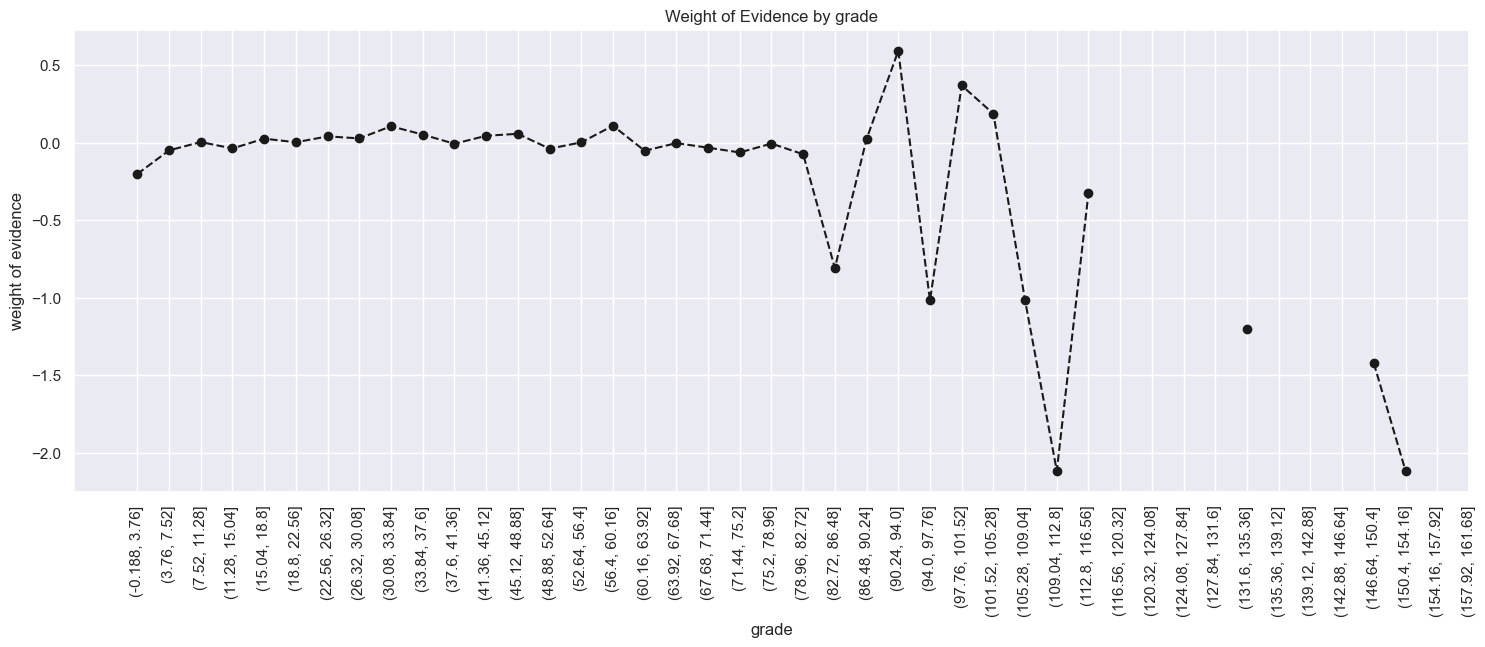

In [187]:
#plot the woe_plot
plot_by_woe(df_temp,90)

In [188]:
###Convert it into binary encoded format by putting 1 and 0 inplace for WoE values that are close to each other

df_inputs_prepr['mths_since_last_delinq:Missing']=np.where(df_inputs_prepr['mths_since_last_delinq'].isnull(),1,0)
df_inputs_prepr['mths_since_last_delinq:0-3']=np.where((df_inputs_prepr['mths_since_last_delinq']<=3)&(df_inputs_prepr['mths_since_last_delinq']>=0),1,0)
df_inputs_prepr['mths_since_last_delinq:4-30']=np.where((df_inputs_prepr['mths_since_last_delinq']<=30)&(df_inputs_prepr['mths_since_last_delinq']>=4),1,0)
df_inputs_prepr['mths_since_last_delinq:31-56']=np.where((df_inputs_prepr['mths_since_last_delinq']<=56)&(df_inputs_prepr['mths_since_last_delinq']>=31),1,0)
df_inputs_prepr['mths_since_last_delinq:>=57']=np.where((df_inputs_prepr['mths_since_last_delinq']>=57),1,0)

In [189]:
df_inputs_test['mths_since_last_delinq:Missing']=np.where(df_inputs_test['mths_since_last_delinq'].isnull(),1,0)
df_inputs_test['mths_since_last_delinq:0-3']=np.where((df_inputs_test['mths_since_last_delinq']<=3)&(df_inputs_test['mths_since_last_delinq']>=0),1,0)
df_inputs_test['mths_since_last_delinq:4-30']=np.where((df_inputs_test['mths_since_last_delinq']<=30)&(df_inputs_test['mths_since_last_delinq']>=4),1,0)
df_inputs_test['mths_since_last_delinq:31-56']=np.where((df_inputs_test['mths_since_last_delinq']<=56)&(df_inputs_test['mths_since_last_delinq']>=31),1,0)
df_inputs_test['mths_since_last_delinq:>=57']=np.where((df_inputs_test['mths_since_last_delinq']>=57),1,0)

In [190]:
df_inputs_prepr['dti']=pd.to_numeric(df_inputs_prepr['dti'])
df_inputs_test['dti']=pd.to_numeric(df_inputs_test['dti'])

In [191]:
#apply the cut function on 'dti_factor'
df_inputs_prepr['dti_factor']=pd.cut(df_inputs_prepr['dti'],50)
df_inputs_test['dti_factor']=pd.cut(df_inputs_test['dti'],50)

In [192]:
#apply the woe_continuos function
df_temp=woe_continuous(df_inputs_prepr,'dti_factor',df_targets_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.04, 0.8]",1553,0.898905,0.004163,1396.0,157.0,0.004202,0.003850,0.087376,NaN,NaN,0.026725
1,"(0.8, 1.6]",1965,0.896692,0.005268,1762.0,203.0,0.005303,0.004978,0.063254,0.002213,0.024122,0.026725
2,"(1.6, 2.399]",2509,0.910323,0.006726,2284.0,225.0,0.006874,0.005518,0.219838,0.013631,0.156584,0.026725
3,"(2.399, 3.199]",3234,0.910019,0.008670,2943.0,291.0,0.008858,0.007136,0.216117,0.000304,0.003722,0.026725
4,"(3.199, 3.999]",4124,0.907856,0.011055,3744.0,380.0,0.011269,0.009319,0.189994,0.002162,0.026123,0.026725
5,"(3.999, 4.799]",5037,0.917213,0.013503,4620.0,417.0,0.013905,0.010226,0.307319,0.009356,0.117325,0.026725
6,"(4.799, 5.599]",5989,0.911671,0.016055,5460.0,529.0,0.016433,0.012973,0.236471,0.005541,0.070848,0.026725
7,"(5.599, 6.398]",6781,0.914909,0.018178,6204.0,577.0,0.018673,0.014150,0.277362,0.003238,0.040892,0.026725
8,"(6.398, 7.198]",7665,0.913372,0.020548,7001.0,664.0,0.021071,0.016283,0.257781,0.001537,0.019581,0.026725
9,"(7.198, 7.998]",8747,0.915514,0.023449,8008.0,739.0,0.024102,0.018123,0.285153,0.002141,0.027372,0.026725


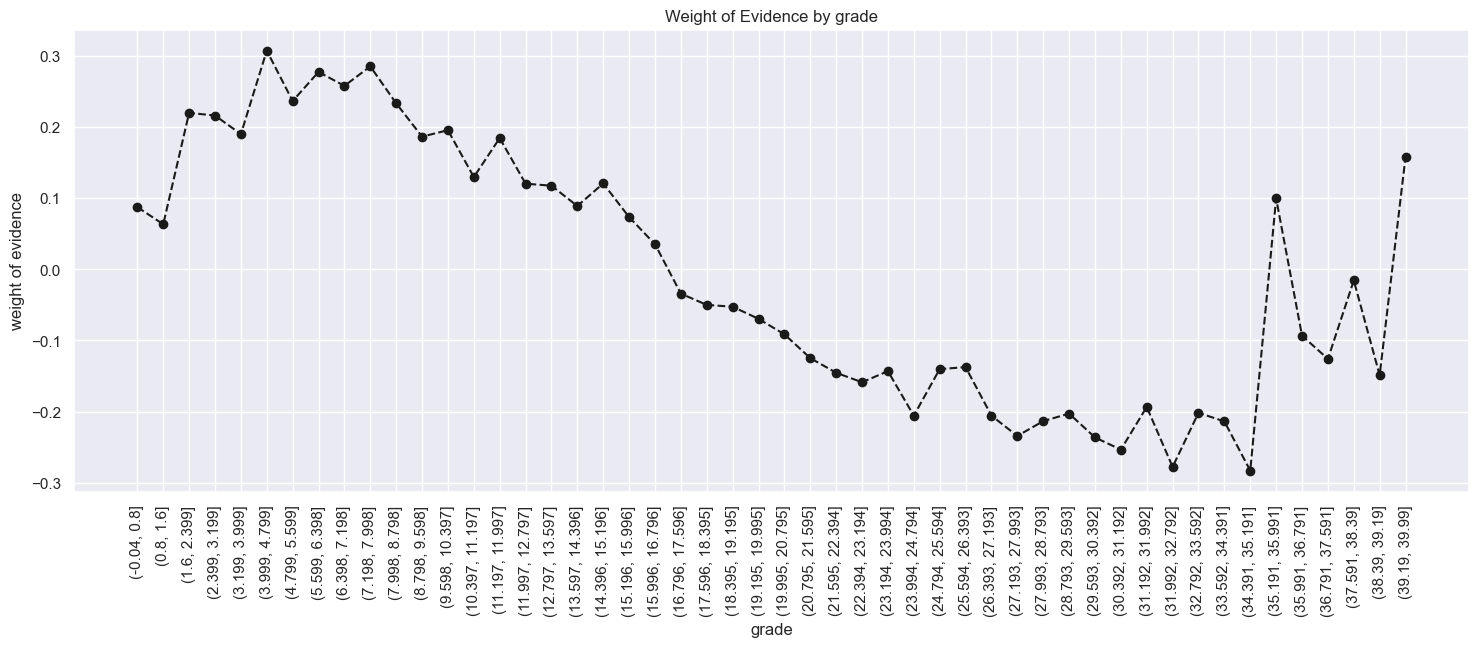

In [193]:
#plot the woe_plot
plot_by_woe(df_temp,90)

In [194]:
###Convert it into binary encoded format by putting 1 and 0 inplace for WoE values that are close to each other

df_inputs_prepr['dti:<5']=np.where((df_inputs_prepr['dti']<=5),1,0)
df_inputs_prepr['dti:5-10']=np.where((df_inputs_prepr['dti']<=10)&(df_inputs_prepr['dti']>5),1,0)
df_inputs_prepr['dti:10-15']=np.where((df_inputs_prepr['dti']<=15)&(df_inputs_prepr['dti']>10),1,0)
df_inputs_prepr['dti:15-20']=np.where((df_inputs_prepr['dti']<=20)&(df_inputs_prepr['dti']>15),1,0)
df_inputs_prepr['dti:20-25']=np.where((df_inputs_prepr['dti']<=25)&(df_inputs_prepr['dti']>20),1,0)
df_inputs_prepr['dti:25-30']=np.where((df_inputs_prepr['dti']<=30)&(df_inputs_prepr['dti']>25),1,0)
df_inputs_prepr['dti:30-35']=np.where((df_inputs_prepr['dti']<=35)&(df_inputs_prepr['dti']>30),1,0)
df_inputs_prepr['dti:35-40']=np.where((df_inputs_prepr['dti']<=40)&(df_inputs_prepr['dti']>35),1,0)
df_inputs_prepr['dti:>40']=np.where((df_inputs_prepr['dti']>40),1,0)

df_inputs_test['dti:<5']=np.where((df_inputs_test['dti']<=5),1,0)
df_inputs_test['dti:5-10']=np.where((df_inputs_test['dti']<=10)&(df_inputs_test['dti']>5),1,0)
df_inputs_test['dti:10-15']=np.where((df_inputs_test['dti']<=15)&(df_inputs_test['dti']>10),1,0)
df_inputs_test['dti:15-20']=np.where((df_inputs_test['dti']<=20)&(df_inputs_test['dti']>15),1,0)
df_inputs_test['dti:20-25']=np.where((df_inputs_test['dti']<=25)&(df_inputs_test['dti']>20),1,0)
df_inputs_test['dti:25-30']=np.where((df_inputs_test['dti']<=30)&(df_inputs_test['dti']>25),1,0)
df_inputs_test['dti:30-35']=np.where((df_inputs_test['dti']<=35)&(df_inputs_test['dti']>30),1,0)
df_inputs_test['dti:35-40']=np.where((df_inputs_test['dti']<=40)&(df_inputs_test['dti']>35),1,0)
df_inputs_test['dti:>40']=np.where((df_inputs_test['dti']>40),1,0)

In [195]:
#'mths_since_last_record' has null values so take only the notnull values
df_inputs_prepr_temp=df_inputs_prepr[pd.notnull(df_inputs_prepr['mths_since_last_record'])]
df_inputs_test_temp=df_inputs_test[pd.notnull(df_inputs_test['mths_since_last_record'])]

#apply the cut function
df_inputs_prepr_temp['mths_since_last_record']=pd.cut(df_inputs_prepr_temp['mths_since_last_record'],50)
df_inputs_test_temp['mths_since_last_record']=pd.cut(df_inputs_test_temp['mths_since_last_record'],50)

In [196]:
#apply the woe_continuos function
df_temp=woe_continuous(df_inputs_prepr,'mths_since_last_record',df_targets_prepr)
df_temp


,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,1041,0.758886,0.020792,790.0,251.0,0.017675,0.046741,-0.972498,NaN,NaN,inf
1,1.0,24,0.916667,0.000479,22.0,2.0,0.000492,0.000372,0.278817,0.157781,1.251315,inf
2,2.0,21,0.857143,0.000419,18.0,3.0,0.000403,0.000559,-0.327319,0.059524,0.606136,inf
3,3.0,36,0.916667,0.000719,33.0,3.0,0.000738,0.000559,0.278817,0.059524,0.606136,inf
4,4.0,40,0.875000,0.000799,35.0,5.0,0.000783,0.000931,-0.173168,0.041667,0.451985,inf
...,...,...,...,...,...,...,...,...,...,...,...,...
117,117.0,616,0.912338,0.012304,562.0,54.0,0.012574,0.010056,0.223439,0.047346,0.485130,inf
118,118.0,620,0.900000,0.012383,558.0,62.0,0.012484,0.011546,0.078146,0.012338,0.145293,inf
119,119.0,368,0.877717,0.007350,323.0,45.0,0.007226,0.008380,-0.148089,0.022283,0.226235,inf
120,120.0,1,1.000000,0.000020,1.0,0.0,0.000022,0.000000,inf,0.122283,inf,inf


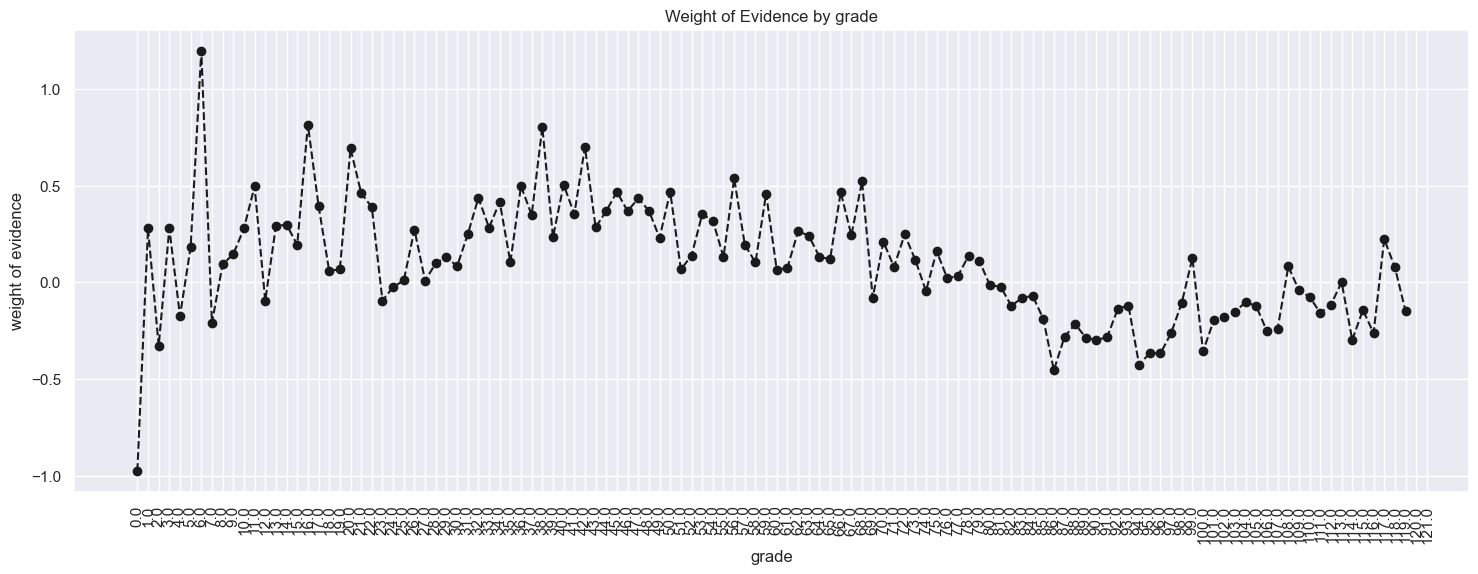

In [197]:
#plot the woe_plot
plot_by_woe(df_temp,90)

In [198]:
###Convert it into binary encoded format by putting 1 and 0 inplace for WoE values that are close to each other

df_inputs_prepr['mths_since_last_record:Missing']=np.where(df_inputs_prepr['mths_since_last_record'].isnull(),1,0)
df_inputs_prepr['mths_since_last_record:0-90']=np.where((df_inputs_prepr['mths_since_last_record']<=90)&(df_inputs_prepr['mths_since_last_record']>=0),1,0)
df_inputs_prepr['mths_since_last_record:90-120']=np.where((df_inputs_prepr['mths_since_last_record']<=120)&(df_inputs_prepr['mths_since_last_record']>=90),1,0)
df_inputs_prepr['mths_since_last_record:120-127']=np.where((df_inputs_prepr['mths_since_last_record']<=127)&(df_inputs_prepr['mths_since_last_record']>=120),1,0)
df_inputs_prepr['mths_since_last_record:>=127']=np.where((df_inputs_prepr['mths_since_last_record']>127),1,0)

df_inputs_test['mths_since_last_record:Missing']=np.where(df_inputs_test['mths_since_last_record'].isnull(),1,0)
df_inputs_test['mths_since_last_record:0-90']=np.where((df_inputs_test['mths_since_last_record']<=90)&(df_inputs_test['mths_since_last_record']>=0),1,0)
df_inputs_test['mths_since_last_record:90-120']=np.where((df_inputs_test['mths_since_last_record']<=120)&(df_inputs_test['mths_since_last_record']>=90),1,0)
df_inputs_test['mths_since_last_record:120-127']=np.where((df_inputs_test['mths_since_last_record']<=127)&(df_inputs_test['mths_since_last_record']>=120),1,0)
df_inputs_test['mths_since_last_record:>=127']=np.where((df_inputs_test['mths_since_last_record']>127),1,0)

In [199]:
#assigning the dataframe into a new variable
loan_data_inputs_train= df_inputs_prepr

In [200]:
loan_data_inputs_train.shape

(373028, 334)

In [201]:
load_ds_targets_train.shape

(373028,)

In [202]:
loan_data_inputs_test=df_inputs_test

In [203]:
loan_data_inputs_test.shape

(93257, 334)

In [204]:
load_ds_targets_test.shape

(93257,)

In [205]:
#import the preprocess dataframe into a new csv file

loan_data_inputs_train.to_csv('loan_data_inputs_train.csv')
load_ds_targets_train.to_csv('loan_data_targets_train.csv')

loan_data_inputs_test.to_csv('loan_data_inputs_test.csv')
load_ds_targets_test.to_csv('loan_data_targets_test.csv')